# Python Notebook for the Study "Rethinking the Boundaries of Camouflaging: A Multivariate Analysis of Sex, Empathizing, Systemizing, and Autistic Traits" by Monteiro et al. (2026)

This notebook contains the statistical analyses conducted for a Maastricht University study of sex differences and trait-specific correlates of autistic camouflaging. It fits and pools hierarchical multivariate models across 20 imputed datasets, evaluates associations with empathizing, systemizing, and autistic traits, conducts sensitivity and stability analyses, and generates the principal figures and tables reported in the manuscript.

The datasets can be found at https://github.com/arasorietnom/CATQ_Multivariate/data/.

When using or adapting these analyses, please cite Monteiro et al. (2026) in addition to the associated repository: https://github.com/arasorietnom/CATQ_Multivariate

# Configs

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.spatial.distance import cdist
from scipy.linalg import eigh

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

import umap
import hdbscan

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset

In [2]:
from google.colab import files
import pandas as pd
import io

# Open local file picker
uploaded = files.upload()

# Load the selected file
filename = next(iter(uploaded))
df = pd.read_csv(
    io.BytesIO(uploaded[filename]),
    sep=None,          # Automatically detects comma, tab, etc.
    engine="python"
)

print(f"Loaded: {filename}")
print(f"Shape: {df.shape}")
display(df.head())

# use UM_autism_hierarchy_imputed_representative.csv !!!

Saving UM_autism_hierarchy_imputed_representative.csv to UM_autism_hierarchy_imputed_representative.csv
Loaded: UM_autism_hierarchy_imputed_representative.csv
Shape: (195, 24)


,ID,sex,age,AQ10_cutoff,EQ,SQ,CAT-Q,AQ10,CAT-Q_comp,CAT-Q_mask,...,AQ10max_imag,AQ10max_soc-skills,AQ10_imputed,AQ10_max_imputed,AQ10max_att-details_imputed,AQ10max_att-switching_imputed,AQ10max_comm_imputed,AQ10max_imag_imputed,AQ10max_soc-skills_imputed,AQ10_max
0,1,1,26,0,22,26,83,2,30,31,...,4,2,0,0,0,0,0,0,0,19
1,2,0,23,0,23,20,84,3,25,32,...,0,2,0,0,0,0,0,0,0,11
2,3,0,20,0,33,23,85,2,21,42,...,2,3,0,0,0,0,0,0,0,18
3,4,0,23,0,39,29,44,5,12,20,...,2,3,0,0,0,0,0,0,0,17
4,5,1,25,0,32,31,107,3,44,36,...,3,3,0,0,0,0,0,0,0,20


# Modelling

Upload UM_autism_hierarchy_imputed_representative.csv.
If you later obtain the multiple-imputation ZIP, you can upload that instead.


Saving UM_autism_hierarchy_imputation_package.zip to UM_autism_hierarchy_imputation_package.zip

Validated 20 completed datasets.
Coefficients and covariance matrices will be pooled with Rubin's rules.

Analysis N = 193: 145 women and 48 men.
Sex code(s) [np.int64(2)] excluded from inferential models because the group was too small.

TABLE 1. Descriptive statistics, mean (SD)


Variable,Overall,Women,Men
N,193,145,48
"Age, years",22.00 (5.53),21.21 (4.56),24.38 (7.33)
EQ,28.41 (8.19),29.46 (8.01),25.23 (7.96)
SQ,18.58 (8.40),16.43 (7.35),25.08 (8.06)
AQ-10,4.12 (2.18),4.12 (2.24),4.10 (2.01)
CAT-Q total,89.29 (20.60),87.23 (20.26),95.50 (20.59)
Compensation,28.33 (9.87),26.90 (9.40),32.62 (10.12)
Masking,35.51 (7.48),35.35 (7.63),36.00 (7.04)
Assimilation,25.45 (8.96),24.98 (9.09),26.88 (8.48)



TABLE 2. Multivariate omnibus tests across model stages


Model,Effect,Wald chi-square,df,p,q_FDR_within_model,Significance
Model 1: sex + age,Men vs women,12.75,3,0.0052,0.0057,**
Model 1: sex + age,Age,12.56,3,0.0057,0.0057,**
"Model 2: + EQ, SQ, AQ-10",Men vs women,3.52,3,0.3178,0.3677,
"Model 2: + EQ, SQ, AQ-10",Age,9.06,3,0.0286,0.0571,
"Model 2: + EQ, SQ, AQ-10",EQ,71.89,3,0.0000,0.0000,***
"Model 2: + EQ, SQ, AQ-10",SQ,8.21,3,0.0418,0.0627,
"Model 2: + EQ, SQ, AQ-10",AQ-10,3.16,3,0.3677,0.3677,
"Model 2: + EQ, SQ, AQ-10","EQ, SQ and AQ-10 jointly",90.62,9,0.0000,0.0000,***
Model 3: + sex interactions,Men vs women,4.22,3,0.2382,0.2858,
Model 3: + sex interactions,Age,6.71,3,0.0816,0.1235,


...

Model,Outcome,Standardized beta,SE,CI_low,CI_high,p,q_FDR_within_model
Model 1: sex + age,Compensation,0.594,0.173,0.253,0.936,0.0007,0.0033
Model 1: sex + age,Masking,0.189,0.165,-0.136,0.514,0.2528,0.3034
Model 1: sex + age,Assimilation,0.268,0.165,-0.057,0.594,0.1052,0.1578
"Model 2: + EQ, SQ, AQ-10",Compensation,0.334,0.191,-0.042,0.711,0.0815,0.2050
"Model 2: + EQ, SQ, AQ-10",Masking,0.251,0.187,-0.118,0.621,0.1816,0.3405
"Model 2: + EQ, SQ, AQ-10",Assimilation,0.053,0.180,-0.301,0.408,0.7676,0.8224
Model 3: + sex interactions,Compensation,0.405,0.225,-0.039,0.849,0.0736,0.2943
Model 3: + sex interactions,Masking,0.240,0.215,-0.185,0.665,0.2662,0.4914
Model 3: + sex interactions,Assimilation,0.227,0.196,-0.160,0.614,0.2479,0.4914



TABLE 4. Separate CAT-Q total models


Model,Predictor,Term_key,Standardized beta,SE,CI_low,CI_high,p,q_FDR_within_model
Model 1: sex + age,Men vs women,Sex,0.470,0.173,0.130,0.810,0.0071,0.0071
Model 1: sex + age,Age,Age,-0.120,0.040,-0.199,-0.042,0.0028,0.0056
"Model 2: + EQ, SQ, AQ-10",Men vs women,Sex,0.274,0.190,-0.100,0.649,0.1496,0.2073
"Model 2: + EQ, SQ, AQ-10",Age,Age,-0.108,0.041,-0.189,-0.027,0.0089,0.0223
"Model 2: + EQ, SQ, AQ-10",EQ,EQ,-0.321,0.074,-0.467,-0.175,0.0000,0.0001
"Model 2: + EQ, SQ, AQ-10",SQ,SQ,0.023,0.103,-0.180,0.226,0.8257,0.8257
"Model 2: + EQ, SQ, AQ-10",AQ-10,AQ10,0.097,0.070,-0.041,0.235,0.1658,0.2073
Model 3: + sex interactions,Men vs women,Sex,0.380,0.210,-0.033,0.794,0.0714,0.1428
Model 3: + sex interactions,Age,Age,-0.096,0.048,-0.192,-0.001,0.0484,0.1428
Model 3: + sex interactions,EQ,EQ,-0.315,0.084,-0.480,-0.151,0.0002,0.0017



TABLE 5. Model fit


Model,Model 1: sex + age,"Model 2: + EQ, SQ, AQ-10",Model 3: + sex interactions
Outcome,,,
Assimilation,0.018,0.215,0.239
CAT-Q total,0.044,0.154,0.171
Compensation,0.064,0.153,0.160
Masking,0.031,0.040,0.068


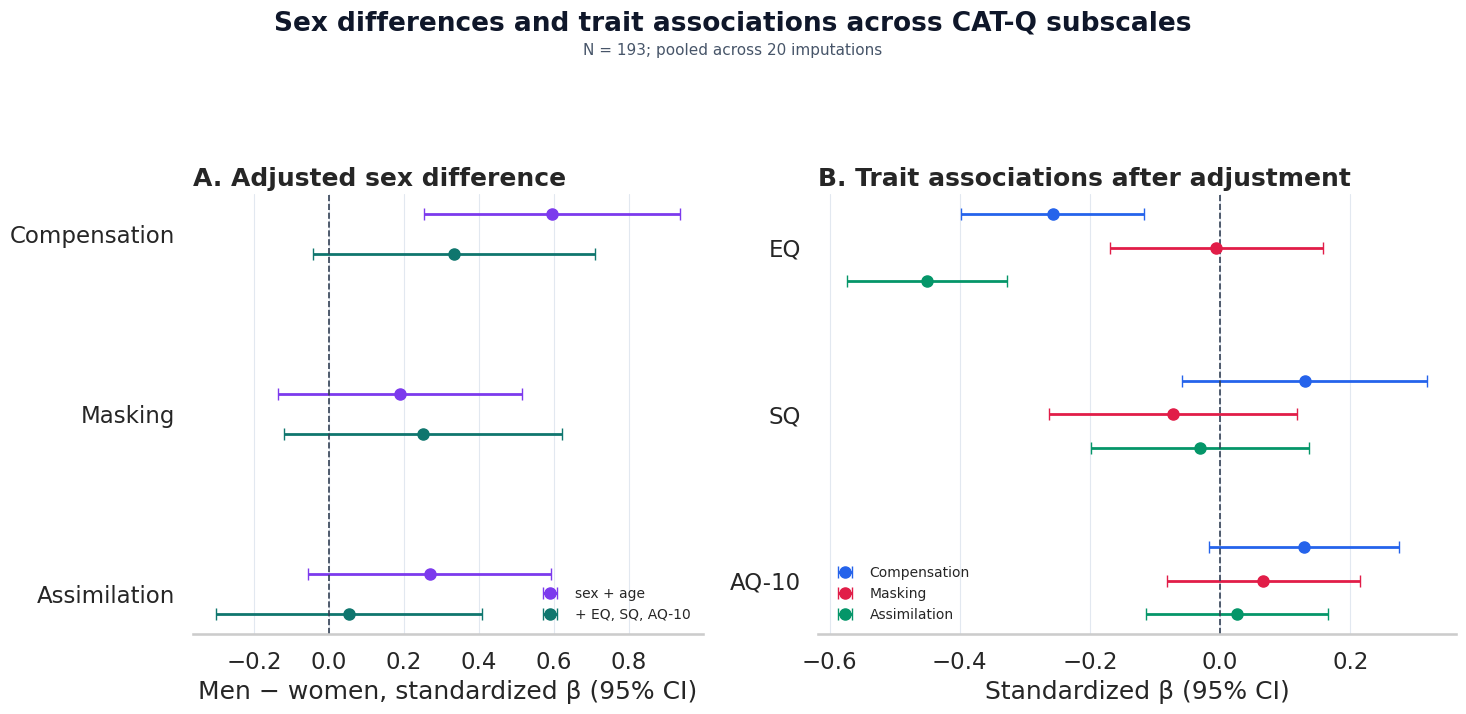


Saved results to: /content/CATQ_primary_staged_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
"""
Model 1: CAT-Q subscales ~ sex + age
Model 2: Model 1 + EQ + SQ + AQ-10
Model 3: Model 2 + sex interactions

CAT-Q total is analysed separately with the same stages.
Accepts either one completed representative CSV or a ZIP/selection of
multiple completed imputation CSV files.
"""

import os
import shutil
import tempfile
import warnings
import zipfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/catq_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

try:
    import jinja2  # noqa: F401
    HAS_STYLER = True
except ImportError:
    HAS_STYLER = False

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------------------

REFERENCE_SEX_CODE = 0
COMPARISON_SEX_CODE = 1
REFERENCE_SEX_LABEL = "Women"
COMPARISON_SEX_LABEL = "Men"

OUTDIR = Path("CATQ_primary_staged_results")
OUTDIR.mkdir(exist_ok=True)

OUTCOMES = {
    "Compensation": "CAT-Q_comp",
    "Masking": "CAT-Q_mask",
    "Assimilation": "CAT-Q_assim",
}

MODEL_TERMS = {
    "Model 1: sex + age": ["Intercept", "Sex", "Age"],
    "Model 2: + EQ, SQ, AQ-10": [
        "Intercept", "Sex", "Age", "EQ", "SQ", "AQ10"
    ],
    "Model 3: + sex interactions": [
        "Intercept", "Sex", "Age", "EQ", "SQ", "AQ10",
        "Sex_x_EQ", "Sex_x_SQ", "Sex_x_AQ10",
    ],
}

TERM_LABELS = {
    "Intercept": "Intercept",
    "Sex": "Men vs women",
    "Age": "Age",
    "EQ": "EQ",
    "SQ": "SQ",
    "AQ10": "AQ-10",
    "Sex_x_EQ": "Sex × EQ",
    "Sex_x_SQ": "Sex × SQ",
    "Sex_x_AQ10": "Sex × AQ-10",
}

REQUIRED = [
    "ID", "sex", "age", "EQ", "SQ", "AQ10", "CAT-Q",
    "CAT-Q_comp", "CAT-Q_mask", "CAT-Q_assim",
]

COLORS = {
    "Compensation": "#2563EB",
    "Masking": "#E11D48",
    "Assimilation": "#059669",
}


# ---------------------------------------------------------------------
# INPUT: CSV OR ZIP
# ---------------------------------------------------------------------

def read_csv_robust(path):
    data = pd.read_csv(
        path,
        sep=None,
        engine="python",
        encoding="utf-8-sig",
    )
    data.columns = (
        data.columns.astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.strip('"')
    )
    return data


def safe_extract(zip_path, destination):
    root = destination.resolve()
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if target != root and root not in target.parents:
                raise ValueError(f"Unsafe ZIP member: {member.filename}")
        archive.extractall(destination)


def collect_csvs(paths):
    csvs = []
    temp_dirs = []

    for path in paths:
        path = Path(path)

        if path.suffix.lower() == ".csv":
            csvs.append(path)

        elif path.suffix.lower() == ".zip":
            temp_dir = Path(tempfile.mkdtemp(prefix="catq_imputations_"))
            temp_dirs.append(temp_dir)
            safe_extract(path, temp_dir)

            preferred = sorted(
                temp_dir.rglob("UM_autism_total_level_imputation_*.csv")
            )
            csvs.extend(preferred or sorted(temp_dir.rglob("*.csv")))

    return list(dict.fromkeys(csvs)), temp_dirs


local_input = os.environ.get("CATQ_INPUT")

if local_input:
    uploaded_paths = [Path(local_input)]
else:
    from google.colab import files

    print(
        "Upload UM_autism_hierarchy_imputed_representative.csv.\n"
        "If you later obtain the multiple-imputation ZIP, you can upload "
        "that instead."
    )
    uploaded = files.upload()
    uploaded_paths = [Path(name) for name in uploaded]

csv_paths, temporary_directories = collect_csvs(uploaded_paths)

if not csv_paths:
    raise FileNotFoundError("No CSV datasets were found.")

datasets = []
reference_ids = None

for csv_path in csv_paths:
    data = read_csv_robust(csv_path)
    missing = [column for column in REQUIRED if column not in data.columns]

    if missing:
        print(f"Skipping {csv_path.name}; missing columns: {missing}")
        continue

    if data["ID"].duplicated().any():
        raise ValueError(f"Duplicate IDs in {csv_path.name}")

    if data[REQUIRED].isna().any().any():
        counts = data[REQUIRED].isna().sum()
        raise ValueError(
            f"{csv_path.name} still contains missing required values:\n"
            f"{counts[counts > 0]}"
        )

    ids = tuple(data["ID"].tolist())
    if reference_ids is None:
        reference_ids = ids
    elif ids != reference_ids:
        raise ValueError("Participant order differs between imputations.")

    datasets.append(data)

if not datasets:
    raise ValueError("No valid analysis-ready dataset was found.")

M = len(datasets)

print(f"\nValidated {M} completed dataset{'s' if M != 1 else ''}.")

if M == 1:
    print(
        "NOTE: This is a single completed dataset analysis. Point estimates "
        "are usable, but between-imputation uncertainty is not represented."
    )
else:
    print("Coefficients and covariance matrices will be pooled with Rubin's rules.")


# ---------------------------------------------------------------------
# MODEL FUNCTIONS
# ---------------------------------------------------------------------

def zscore(values):
    values = pd.to_numeric(values, errors="coerce")
    sd = values.std(ddof=1)
    if pd.isna(sd) or sd == 0:
        raise ValueError(f"Cannot standardize {values.name}")
    return (values - values.mean()) / sd


def prepare_data(data):
    model_data = data[
        data["sex"].isin([REFERENCE_SEX_CODE, COMPARISON_SEX_CODE])
    ].copy()

    model_data["Sex"] = (
        model_data["sex"] == COMPARISON_SEX_CODE
    ).astype(float)

    for source, target in [
        ("age", "Age"),
        ("EQ", "EQ"),
        ("SQ", "SQ"),
        ("AQ10", "AQ10"),
        ("CAT-Q", "CATQ_total"),
    ]:
        model_data[f"{target}_z"] = zscore(model_data[source])

    for label, source in OUTCOMES.items():
        model_data[f"{label}_z"] = zscore(model_data[source])

    model_data["Sex_x_EQ"] = model_data["Sex"] * model_data["EQ_z"]
    model_data["Sex_x_SQ"] = model_data["Sex"] * model_data["SQ_z"]
    model_data["Sex_x_AQ10"] = model_data["Sex"] * model_data["AQ10_z"]

    columns = {
        "Intercept": np.ones(len(model_data)),
        "Sex": model_data["Sex"].to_numpy(),
        "Age": model_data["Age_z"].to_numpy(),
        "EQ": model_data["EQ_z"].to_numpy(),
        "SQ": model_data["SQ_z"].to_numpy(),
        "AQ10": model_data["AQ10_z"].to_numpy(),
        "Sex_x_EQ": model_data["Sex_x_EQ"].to_numpy(),
        "Sex_x_SQ": model_data["Sex_x_SQ"].to_numpy(),
        "Sex_x_AQ10": model_data["Sex_x_AQ10"].to_numpy(),
    }

    subscale_y = np.column_stack(
        [model_data[f"{name}_z"] for name in OUTCOMES]
    ).astype(float)

    total_y = model_data[["CATQ_total_z"]].to_numpy(dtype=float)
    return model_data, columns, subscale_y, total_y


def fit_multivariate_hc3(X, Y):
    """Multivariate OLS with cross-outcome HC3 sandwich covariance."""
    n, p = X.shape
    q = Y.shape[1]
    xtx_inv = np.linalg.pinv(X.T @ X)
    beta = xtx_inv @ X.T @ Y
    residuals = Y - X @ beta
    leverage = np.sum((X @ xtx_inv) * X, axis=1)

    bread = np.kron(np.eye(q), xtx_inv)
    meat = np.zeros((p * q, p * q))

    for i in range(n):
        x_i = X[i][:, None]
        e_i = residuals[i][:, None]
        denominator = max((1 - leverage[i]) ** 2, 1e-12)
        meat += np.kron(e_i @ e_i.T, x_i @ x_i.T) / denominator

    covariance = bread @ meat @ bread

    r2 = []
    for j in range(q):
        sse = np.sum(residuals[:, j] ** 2)
        sst = np.sum((Y[:, j] - Y[:, j].mean()) ** 2)
        r2.append(1 - sse / sst)

    return {
        "beta": beta,
        "covariance": covariance,
        "r2": np.asarray(r2),
        "residual_correlation": (
            np.corrcoef(residuals, rowvar=False)
            if q > 1 else np.array([[1.0]])
        ),
        "n": n,
        "df_residual": n - p,
    }


def pool_fits(fits):
    estimates = np.stack(
        [fit["beta"].flatten(order="F") for fit in fits]
    )
    covariances = np.stack([fit["covariance"] for fit in fits])

    qbar = estimates.mean(axis=0)
    ubar = covariances.mean(axis=0)

    if len(fits) > 1:
        between = np.cov(estimates, rowvar=False, ddof=1)
    else:
        between = np.zeros_like(ubar)

    total = ubar + (1 + 1 / len(fits)) * between

    relative_increase = (
        (1 + 1 / len(fits))
        * np.diag(between)
        / np.maximum(np.diag(ubar), 1e-15)
    )

    dfs = np.full(len(qbar), fits[0]["df_residual"], dtype=float)
    valid = relative_increase > 1e-12

    if len(fits) > 1:
        dfs[valid] = (
            (len(fits) - 1)
            * (1 + 1 / relative_increase[valid]) ** 2
        )
        dfs = np.minimum(dfs, fits[0]["df_residual"])

    return {
        "estimate": qbar,
        "covariance": total,
        "df": dfs,
        "n": fits[0]["n"],
        "m": len(fits),
    }


def bh_fdr(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)
    ranked = values[order]
    adjusted = ranked * len(values) / np.arange(1, len(values) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    output = np.empty(len(values))
    output[order] = np.clip(adjusted, 0, 1)
    return output


def stars(p):
    if p < .001:
        return "***"
    if p < .01:
        return "**"
    if p < .05:
        return "*"
    return ""


def coefficient_index(outcome_index, term_index, number_terms):
    return outcome_index * number_terms + term_index


def fit_all_models():
    prepared = [prepare_data(data) for data in datasets]
    results = {}

    for model_name, terms in MODEL_TERMS.items():
        subscale_fits = []
        total_fits = []

        for _, columns, subscale_y, total_y in prepared:
            X = np.column_stack([columns[term] for term in terms])
            subscale_fits.append(fit_multivariate_hc3(X, subscale_y))
            total_fits.append(fit_multivariate_hc3(X, total_y))

        results[model_name] = {
            "terms": terms,
            "subscale_fits": subscale_fits,
            "total_fits": total_fits,
            "subscale_pool": pool_fits(subscale_fits),
            "total_pool": pool_fits(total_fits),
        }

    return prepared, results


prepared_datasets, model_results = fit_all_models()
analysis_n = model_results["Model 1: sex + age"]["subscale_pool"]["n"]

other_codes = sorted(
    set(datasets[0]["sex"].dropna().unique())
    - {REFERENCE_SEX_CODE, COMPARISON_SEX_CODE}
)

print(f"\nAnalysis N = {analysis_n}: 145 women and 48 men.")
if other_codes:
    print(
        f"Sex code(s) {other_codes} excluded from inferential models "
        "because the group was too small."
    )


# ---------------------------------------------------------------------
# TABLE 1: DESCRIPTIVES
# ---------------------------------------------------------------------

def pooled_description(column, sex_code=None):
    means, variances = [], []

    for data in datasets:
        sample = data[
            data["sex"].isin([REFERENCE_SEX_CODE, COMPARISON_SEX_CODE])
        ]
        if sex_code is not None:
            sample = sample[sample["sex"] == sex_code]

        values = pd.to_numeric(sample[column], errors="coerce")
        means.append(values.mean())
        variances.append(values.var(ddof=1))

    variance = np.mean(variances)
    if len(means) > 1:
        variance += np.var(means, ddof=1)

    return f"{np.mean(means):.2f} ({np.sqrt(variance):.2f})"


descriptive_variables = {
    "Age, years": "age",
    "EQ": "EQ",
    "SQ": "SQ",
    "AQ-10": "AQ10",
    "CAT-Q total": "CAT-Q",
    "Compensation": "CAT-Q_comp",
    "Masking": "CAT-Q_mask",
    "Assimilation": "CAT-Q_assim",
}

counts = datasets[0][
    datasets[0]["sex"].isin([REFERENCE_SEX_CODE, COMPARISON_SEX_CODE])
]["sex"].value_counts()

descriptive_rows = [{
    "Variable": "N",
    "Overall": analysis_n,
    "Women": int(counts.get(REFERENCE_SEX_CODE, 0)),
    "Men": int(counts.get(COMPARISON_SEX_CODE, 0)),
}]

for label, column in descriptive_variables.items():
    descriptive_rows.append({
        "Variable": label,
        "Overall": pooled_description(column),
        "Women": pooled_description(column, REFERENCE_SEX_CODE),
        "Men": pooled_description(column, COMPARISON_SEX_CODE),
    })

table_1 = pd.DataFrame(descriptive_rows)


# ---------------------------------------------------------------------
# TABLE 2: ALL POOLED COEFFICIENTS
# ---------------------------------------------------------------------

coefficient_rows = []

for model_name, result in model_results.items():
    terms = result["terms"]
    pool = result["subscale_pool"]
    number_terms = len(terms)

    for outcome_index, outcome in enumerate(OUTCOMES):
        for term_index, term in enumerate(terms):
            if term == "Intercept":
                continue

            index = coefficient_index(
                outcome_index, term_index, number_terms
            )
            estimate = pool["estimate"][index]
            se = np.sqrt(pool["covariance"][index, index])
            df = pool["df"][index]
            t_value = estimate / se
            p_value = 2 * stats.t.sf(abs(t_value), df)
            critical = stats.t.ppf(.975, df)

            coefficient_rows.append({
                "Model": model_name,
                "Outcome": outcome,
                "Term_key": term,
                "Predictor": TERM_LABELS[term],
                "Standardized beta": estimate,
                "SE": se,
                "CI_low": estimate - critical * se,
                "CI_high": estimate + critical * se,
                "t": t_value,
                "df": df,
                "p": p_value,
            })

table_2 = pd.DataFrame(coefficient_rows)
table_2["q_FDR_within_model"] = np.nan

for model_name in table_2["Model"].unique():
    mask = table_2["Model"] == model_name
    table_2.loc[mask, "q_FDR_within_model"] = bh_fdr(
        table_2.loc[mask, "p"]
    )

table_2["Significance"] = table_2["q_FDR_within_model"].apply(stars)


# ---------------------------------------------------------------------
# TABLE 3: MULTIVARIATE OMNIBUS TESTS
# ---------------------------------------------------------------------

omnibus_rows = []

for model_name, result in model_results.items():
    terms = result["terms"]
    pool = result["subscale_pool"]
    number_terms = len(terms)

    tests = [(TERM_LABELS[term], [term]) for term in terms if term != "Intercept"]

    if model_name == "Model 2: + EQ, SQ, AQ-10":
        tests.append(("EQ, SQ and AQ-10 jointly", ["EQ", "SQ", "AQ10"]))

    if model_name == "Model 3: + sex interactions":
        tests.append((
            "All sex interactions",
            ["Sex_x_EQ", "Sex_x_SQ", "Sex_x_AQ10"],
        ))

    for effect, tested_terms in tests:
        indices = []

        for outcome_index in range(len(OUTCOMES)):
            for term in tested_terms:
                indices.append(
                    coefficient_index(
                        outcome_index,
                        terms.index(term),
                        number_terms,
                    )
                )

        indices = np.asarray(indices)
        estimates = pool["estimate"][indices]
        covariance = pool["covariance"][np.ix_(indices, indices)]
        wald = float(
            estimates.T @ np.linalg.pinv(covariance) @ estimates
        )
        degrees = len(indices)
        p_value = stats.chi2.sf(wald, degrees)

        omnibus_rows.append({
            "Model": model_name,
            "Effect": effect,
            "Wald chi-square": wald,
            "df": degrees,
            "p": p_value,
        })

table_3 = pd.DataFrame(omnibus_rows)
table_3["q_FDR_within_model"] = np.nan

for model_name in table_3["Model"].unique():
    mask = table_3["Model"] == model_name
    table_3.loc[mask, "q_FDR_within_model"] = bh_fdr(
        table_3.loc[mask, "p"]
    )

table_3["Significance"] = table_3["q_FDR_within_model"].apply(stars)


# ---------------------------------------------------------------------
# TABLE 4: SEX EFFECT ACROSS MODEL STAGES
# ---------------------------------------------------------------------

table_4 = table_2[
    table_2["Term_key"] == "Sex"
][[
    "Model", "Outcome", "Standardized beta", "SE",
    "CI_low", "CI_high", "p", "q_FDR_within_model",
]].copy()


# ---------------------------------------------------------------------
# TABLE 5: SEPARATE CAT-Q TOTAL MODELS
# ---------------------------------------------------------------------

total_rows = []

for model_name, result in model_results.items():
    terms = result["terms"]
    pool = result["total_pool"]

    for term_index, term in enumerate(terms):
        if term == "Intercept":
            continue

        estimate = pool["estimate"][term_index]
        se = np.sqrt(pool["covariance"][term_index, term_index])
        df = pool["df"][term_index]
        t_value = estimate / se
        p_value = 2 * stats.t.sf(abs(t_value), df)
        critical = stats.t.ppf(.975, df)

        total_rows.append({
            "Model": model_name,
            "Predictor": TERM_LABELS[term],
            "Term_key": term,
            "Standardized beta": estimate,
            "SE": se,
            "CI_low": estimate - critical * se,
            "CI_high": estimate + critical * se,
            "p": p_value,
        })

table_5 = pd.DataFrame(total_rows)
table_5["q_FDR_within_model"] = np.nan

for model_name in table_5["Model"].unique():
    mask = table_5["Model"] == model_name
    table_5.loc[mask, "q_FDR_within_model"] = bh_fdr(
        table_5.loc[mask, "p"]
    )


# ---------------------------------------------------------------------
# TABLE 6: MODEL FIT
# ---------------------------------------------------------------------

fit_rows = []

for model_name, result in model_results.items():
    subscale_r2 = np.stack(
        [fit["r2"] for fit in result["subscale_fits"]]
    ).mean(axis=0)
    total_r2 = np.stack(
        [fit["r2"] for fit in result["total_fits"]]
    ).mean(axis=0)[0]

    for outcome, value in zip(OUTCOMES, subscale_r2):
        fit_rows.append({
            "Model": model_name,
            "Outcome": outcome,
            "R_squared": value,
        })

    fit_rows.append({
        "Model": model_name,
        "Outcome": "CAT-Q total",
        "R_squared": total_r2,
    })

table_6 = pd.DataFrame(fit_rows)


# ---------------------------------------------------------------------
# DISPLAY PRIMARY RESULTS
# ---------------------------------------------------------------------

print("\nTABLE 1. Descriptive statistics, mean (SD)")
display(table_1.style.hide(axis="index") if HAS_STYLER else table_1)

print("\nTABLE 2. Multivariate omnibus tests across model stages")
display(
    table_3.style.hide(axis="index").format({
        "Wald chi-square": "{:.2f}",
        "p": "{:.4f}",
        "q_FDR_within_model": "{:.4f}",
    }) if HAS_STYLER else table_3
)

print("\nTABLE 3. Adjusted sex effect across model stages")
display(
    table_4.style.hide(axis="index").format({
        "Standardized beta": "{:.3f}",
        "SE": "{:.3f}",
        "CI_low": "{:.3f}",
        "CI_high": "{:.3f}",
        "p": "{:.4f}",
        "q_FDR_within_model": "{:.4f}",
    }) if HAS_STYLER else table_4
)

print("\nTABLE 4. Separate CAT-Q total models")
display(
    table_5.style.hide(axis="index").format({
        "Standardized beta": "{:.3f}",
        "SE": "{:.3f}",
        "CI_low": "{:.3f}",
        "CI_high": "{:.3f}",
        "p": "{:.4f}",
        "q_FDR_within_model": "{:.4f}",
    }) if HAS_STYLER else table_5
)

print("\nTABLE 5. Model fit")
model_fit_display = table_6.pivot(
        index="Outcome",
        columns="Model",
        values="R_squared",
    )
display(
    model_fit_display.style.format("{:.3f}").background_gradient(
        cmap="Blues", axis=None
    ) if HAS_STYLER else model_fit_display
)


# ---------------------------------------------------------------------
# FIGURE: HOW ADJUSTMENT CHANGES THE SEX EFFECT
# ---------------------------------------------------------------------

sns.set_theme(style="whitegrid", context="talk")

figure, axes = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={"width_ratios": [1, 1.25]},
)

# Panel A: sex coefficient in Model 1 and Model 2.
sex_plot = table_4[
    table_4["Model"].isin([
        "Model 1: sex + age",
        "Model 2: + EQ, SQ, AQ-10",
    ])
].copy()

model_offsets = {
    "Model 1: sex + age": 0.11,
    "Model 2: + EQ, SQ, AQ-10": -0.11,
}

model_colors = {
    "Model 1: sex + age": "#7C3AED",
    "Model 2: + EQ, SQ, AQ-10": "#0F766E",
}

y_base = np.arange(len(OUTCOMES))[::-1]

for model_name in model_offsets:
    subset = (
        sex_plot[sex_plot["Model"] == model_name]
        .set_index("Outcome")
        .loc[list(OUTCOMES)]
    )
    estimates = subset["Standardized beta"].to_numpy()
    axes[0].errorbar(
        estimates,
        y_base + model_offsets[model_name],
        xerr=[
            estimates - subset["CI_low"].to_numpy(),
            subset["CI_high"].to_numpy() - estimates,
        ],
        fmt="o",
        markersize=8,
        linewidth=2,
        capsize=4,
        color=model_colors[model_name],
        label=model_name.replace("Model 1: ", "").replace("Model 2: ", ""),
    )

axes[0].axvline(0, color="#334155", linestyle="--", linewidth=1.2)
axes[0].set_yticks(y_base)
axes[0].set_yticklabels(list(OUTCOMES))
axes[0].set_xlabel("Men − women, standardized β (95% CI)")
axes[0].set_title("A. Adjusted sex difference", loc="left", weight="bold")
axes[0].legend(frameon=False, fontsize=10)

# Panel B: EQ, SQ and AQ-10 in Model 2.
explanatory = table_2[
    (table_2["Model"] == "Model 2: + EQ, SQ, AQ-10")
    & table_2["Term_key"].isin(["EQ", "SQ", "AQ10"])
].copy()

predictors = ["EQ", "SQ", "AQ10"]
predictor_positions = np.arange(len(predictors))[::-1]
outcome_offsets = {
    "Compensation": .20,
    "Masking": 0,
    "Assimilation": -.20,
}

for outcome in OUTCOMES:
    subset = (
        explanatory[explanatory["Outcome"] == outcome]
        .set_index("Term_key")
        .loc[predictors]
    )
    estimates = subset["Standardized beta"].to_numpy()

    axes[1].errorbar(
        estimates,
        predictor_positions + outcome_offsets[outcome],
        xerr=[
            estimates - subset["CI_low"].to_numpy(),
            subset["CI_high"].to_numpy() - estimates,
        ],
        fmt="o",
        markersize=8,
        linewidth=2,
        capsize=4,
        color=COLORS[outcome],
        label=outcome,
    )

axes[1].axvline(0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set_yticks(predictor_positions)
axes[1].set_yticklabels(["EQ", "SQ", "AQ-10"])
axes[1].set_xlabel("Standardized β (95% CI)")
axes[1].set_title(
    "B. Trait associations after adjustment",
    loc="left",
    weight="bold",
)
axes[1].legend(frameon=False, fontsize=10)

for axis in axes:
    axis.grid(axis="x", color="#E2E8F0", linewidth=.8)
    axis.grid(axis="y", visible=False)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)

figure.suptitle(
    "Sex differences and trait associations across CAT-Q subscales",
    fontsize=19,
    weight="bold",
    color="#0F172A",
    y=1.03,
)

figure.text(
    .5, .965,
    (
        f"N = {analysis_n}; "
        f"{'single completed dataset' if M == 1 else f'pooled across {M} imputations'}"
    ),
    ha="center",
    fontsize=11,
    color="#475569",
)

figure.tight_layout(rect=[0, 0, 1, .92])

figure.savefig(
    OUTDIR / "Figure_primary_staged_CATQ_models.png",
    dpi=350,
    bbox_inches="tight",
    facecolor="white",
)
figure.savefig(
    OUTDIR / "Figure_primary_staged_CATQ_models.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ---------------------------------------------------------------------
# EXPORT
# ---------------------------------------------------------------------

tables = {
    "Table_1_descriptives": table_1,
    "Table_2_coefficients": table_2,
    "Table_3_omnibus": table_3,
    "Table_4_sex_effects": table_4,
    "Table_5_CATQ_total": table_5,
    "Table_6_model_fit": table_6,
}

for name, table in tables.items():
    table.to_csv(OUTDIR / f"{name}.csv", index=False)

with pd.ExcelWriter(
    OUTDIR / "CATQ_primary_staged_tables.xlsx",
    engine="openpyxl",
) as writer:
    for name, table in tables.items():
        table.to_excel(writer, sheet_name=name[:31], index=False)

notes = f"""
Primary staged CAT-Q analysis
=============================

Analysis N: {analysis_n}
Women: {int(counts.get(REFERENCE_SEX_CODE, 0))}
Men: {int(counts.get(COMPARISON_SEX_CODE, 0))}
Completed datasets: {M}

Model 1 estimates the age-adjusted overall sex difference.
Model 2 evaluates whether sex differences persist after additionally
adjusting for EQ, SQ and AQ-10.
Model 3 evaluates whether EQ, SQ and AQ-10 associations differ between
women and men.

CAT-Q total was analysed separately because it is the exact sum of the
three subscales and cannot be included jointly with them.

Outcomes and continuous predictors were standardized. HC3 robust
cross-outcome covariance matrices were used. When multiple completed
datasets were supplied, estimates and covariance matrices were pooled
using Rubin's rules.

If only one representative completed dataset was supplied, the results
do not include between-imputation uncertainty and should be replaced by
the multiply imputed analysis for final manuscript inference.
""".strip()

(OUTDIR / "Analysis_notes.txt").write_text(notes, encoding="utf-8")

archive = shutil.make_archive(
    "CATQ_primary_staged_results",
    "zip",
    root_dir=OUTDIR,
)

print(f"\nSaved results to: {archive}")

if not local_input:
    files.download(archive)


SUPPLEMENTARY TABLE 1. Sex-specific simple slopes


Outcome,Predictor,Group,Standardized_slope,SE,CI_low,CI_high,t,df,p,q_FDR,Significance
Compensation,EQ,Women,-0.242,0.081,-0.402,-0.083,-2.99,184.0,0.0032,0.0284,*
Compensation,EQ,Men,-0.307,0.157,-0.617,0.004,-1.95,184.0,0.0529,0.1881,
Compensation,SQ,Women,0.180,0.107,-0.032,0.392,1.67,184.0,0.0959,0.2158,
Compensation,SQ,Men,-0.006,0.185,-0.371,0.358,-0.03,184.0,0.9723,0.9723,
Compensation,AQ-10,Women,0.129,0.086,-0.039,0.298,1.51,184.0,0.1322,0.2643,
Compensation,AQ-10,Men,0.106,0.160,-0.210,0.422,0.66,184.0,0.5093,0.7052,
Masking,EQ,Women,0.021,0.093,-0.163,0.205,0.22,184.0,0.8234,0.8734,
Masking,EQ,Men,-0.041,0.186,-0.408,0.325,-0.22,184.0,0.8249,0.8734,
Masking,SQ,Women,-0.101,0.104,-0.306,0.104,-0.97,184.0,0.3321,0.5210,
Masking,SQ,Men,-0.070,0.209,-0.482,0.342,-0.34,184.0,0.7373,0.8734,



SUPPLEMENTARY TABLE 2. Joint multivariate interaction tests


Model,Effect,Wald chi-square,df,p,q_FDR_within_model,Significance
Model 3: + sex interactions,Sex × EQ,1.48,3,0.6879,0.6879,
Model 3: + sex interactions,Sex × SQ,6.69,3,0.0824,0.1235,
Model 3: + sex interactions,Sex × AQ-10,12.34,3,0.0063,0.0283,*
Model 3: + sex interactions,All sex interactions,17.51,9,0.0413,0.0930,


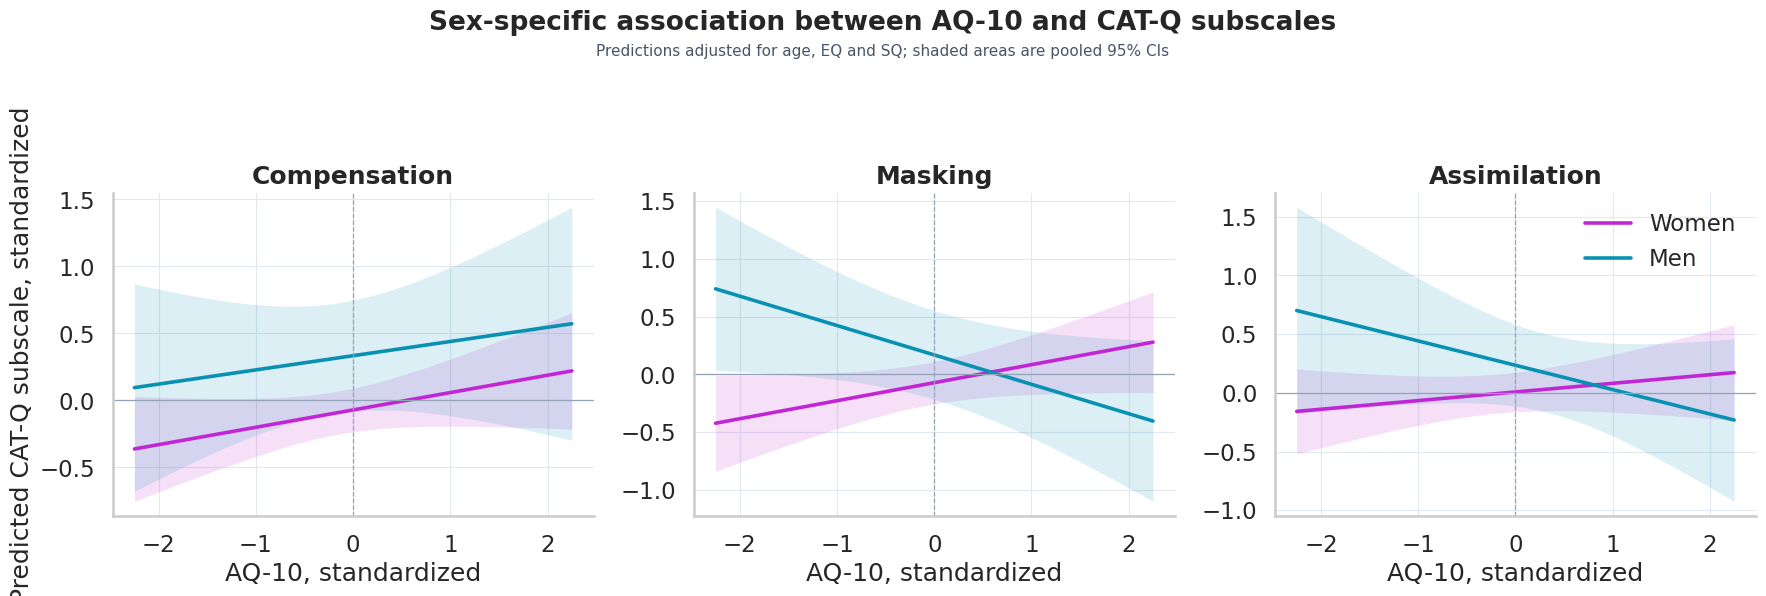


SUPPLEMENTARY TABLE 3. Restricted cubic-spline nonlinearity tests
Spline knots on standardized AQ-10: [-1.446 -0.51   0.427  1.832]


Outcome_set,Wald_chi_square,df,p,q_FDR
CAT-Q subscales jointly,3.40,6,0.7578,0.7578
CAT-Q total,1.95,2,0.3766,0.7532



SUPPLEMENTARY TABLE 4. Influence summary


Outcome,Mean_N_flagged,Maximum_N_flagged,Maximum_Cooks_D,Maximum_leverage
Assimilation,8.2,9,0.098,0.298
Compensation,16.0,16,0.089,0.298
Masking,15.1,16,0.144,0.298



SUPPLEMENTARY TABLE 5. Sex-group overlap


Propensity_AUC,Common_support_low,Common_support_high,N_outside_common_support,Percent_outside_common_support
0.837,0.012,0.843,15,7.8



Standardized mean differences: men minus women


Variable,Standardized_mean_difference_men_minus_women
AQ-10,-0.008
Age,0.588
EQ,-0.529
SQ,1.149



Variance inflation factors


Predictor,VIF
Age,1.10
EQ,1.00
SQ,1.10
AQ-10,1.00


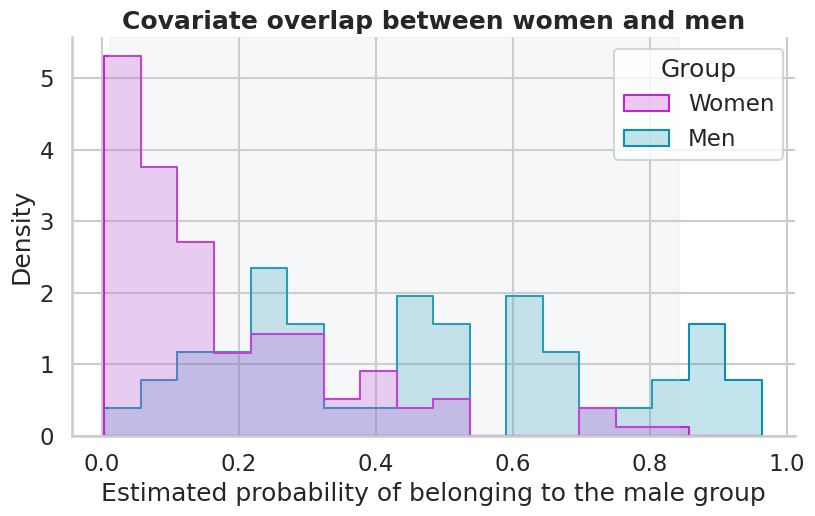


SUPPLEMENTARY TABLE 6. Shapley R² decomposition


Outcome,Baseline_sex_age_R2,EQ_contribution,SQ_contribution,AQ10_contribution,Full_model_R2
Assimilation,0.018,0.192,0.004,0.002,0.215
CAT-Q total,0.044,0.098,0.000,0.012,0.154
Compensation,0.064,0.060,0.010,0.019,0.153
Masking,0.031,0.000,0.004,0.004,0.040


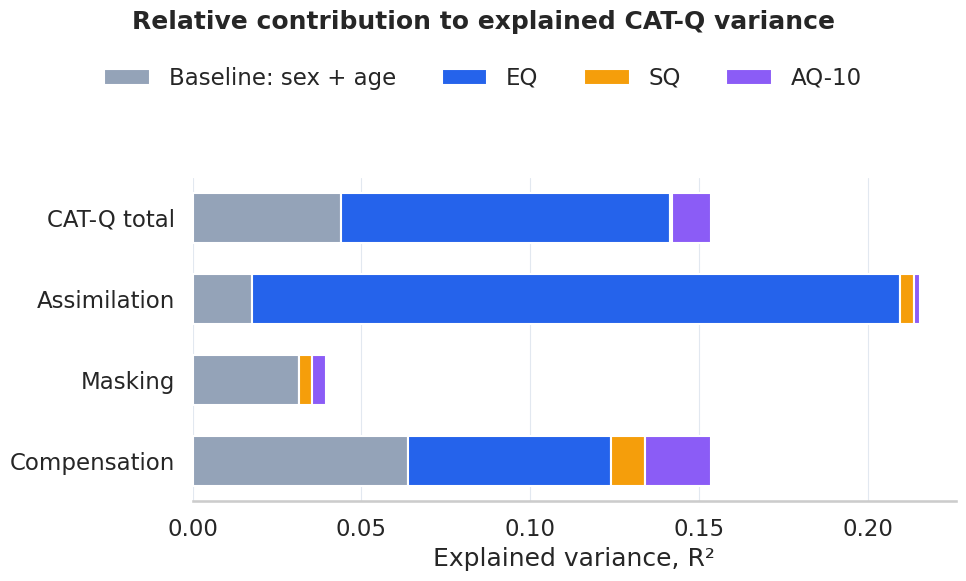


SUPPLEMENTARY TABLE 7. AQ-10 cutoff multivariate tests


Effect,Wald_chi_square,df,p,q_FDR
AQ-10 cutoff,10.93,3,0.0121,0.0121
Sex × AQ-10 cutoff,13.17,3,0.0043,0.0086



SUPPLEMENTARY TABLE 8. AQ-10 cutoff coefficients


Outcome,Effect,Standardized_beta,SE,CI_low,CI_high,p,q_FDR
Compensation,AQ-10 cutoff,0.451,0.186,0.085,0.817,0.0161,0.0322
Compensation,Sex × AQ-10 cutoff,-0.422,0.447,-1.303,0.460,0.3465,0.3465
Masking,AQ-10 cutoff,0.566,0.182,0.206,0.926,0.0022,0.0068
Masking,Sex × AQ-10 cutoff,-0.968,0.313,-1.585,-0.352,0.0023,0.0068
Assimilation,AQ-10 cutoff,0.260,0.181,-0.096,0.617,0.1517,0.1821
Assimilation,Sex × AQ-10 cutoff,-0.525,0.361,-1.238,0.187,0.1474,0.1821



Saved supplementary results to: /content/CATQ_supplementary_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
"""
Second Colab cell for the CAT-Q analysis.

Run this only after CATQ_primary_staged_colab_cell.py in the same notebook.
It adds:
  1. pooled simple slopes for women and men;
  2. AQ-10 × sex predicted-value plots;
  3. joint interaction results;
  4. restricted cubic-spline nonlinearity checks;
  5. influence, overlap, and collinearity diagnostics;
  6. exact Shapley R² variance decomposition;
  7. AQ-10 cutoff sensitivity analyses.
"""

import itertools
import math
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ---------------------------------------------------------------------
# REQUIRE THE FIRST CELL
# ---------------------------------------------------------------------

required_objects = [
    "datasets", "model_results", "MODEL_TERMS", "OUTCOMES",
    "prepare_data", "fit_multivariate_hc3", "pool_fits",
    "coefficient_index", "bh_fdr", "display",
]

missing_objects = [
    name for name in required_objects if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the first staged-model cell before this cell. "
        f"Missing objects: {missing_objects}"
    )

SUPP_DIR = Path("CATQ_supplementary_results")
SUPP_DIR.mkdir(exist_ok=True)

MODEL3_NAME = "Model 3: + sex interactions"
MODEL3_TERMS = MODEL_TERMS[MODEL3_NAME]
MODEL3_RESULT = model_results[MODEL3_NAME]


# ---------------------------------------------------------------------
# GENERAL CONTRAST AND TEST FUNCTIONS
# ---------------------------------------------------------------------

def pool_scalar_contrast(fits, contrast):
    """Pool an arbitrary scalar linear contrast using Rubin's rules."""

    estimates = []
    within_variances = []

    contrast = np.asarray(contrast, dtype=float)

    for fit in fits:
        beta_vector = fit["beta"].flatten(order="F")
        estimates.append(float(contrast @ beta_vector))
        within_variances.append(
            float(contrast @ fit["covariance"] @ contrast)
        )

    estimates = np.asarray(estimates)
    within_variances = np.asarray(within_variances)

    estimate = estimates.mean()
    within = within_variances.mean()
    between = estimates.var(ddof=1) if len(fits) > 1 else 0.0
    total_variance = within + (1 + 1 / len(fits)) * between
    se = np.sqrt(max(total_variance, 0))

    df_complete = fits[0]["df_residual"]

    if between > 1e-15 and len(fits) > 1:
        relative_increase = (
            (1 + 1 / len(fits)) * between / max(within, 1e-15)
        )
        df = (len(fits) - 1) * (1 + 1 / relative_increase) ** 2
        df = min(df, df_complete)
    else:
        df = df_complete

    statistic = estimate / se
    p_value = 2 * stats.t.sf(abs(statistic), df)
    critical = stats.t.ppf(.975, df)

    return {
        "estimate": estimate,
        "SE": se,
        "CI_low": estimate - critical * se,
        "CI_high": estimate + critical * se,
        "t": statistic,
        "df": df,
        "p": p_value,
    }


def pooled_wald(pool, indices):
    indices = np.asarray(indices, dtype=int)
    estimates = pool["estimate"][indices]
    covariance = pool["covariance"][np.ix_(indices, indices)]
    wald = float(
        estimates.T @ np.linalg.pinv(covariance) @ estimates
    )
    degrees = len(indices)

    return {
        "Wald_chi_square": wald,
        "df": degrees,
        "p": stats.chi2.sf(wald, degrees),
    }


# ---------------------------------------------------------------------
# 1. SIMPLE SLOPES FOR WOMEN AND MEN
# ---------------------------------------------------------------------

simple_slope_rows = []
number_terms = len(MODEL3_TERMS)
number_parameters = number_terms * len(OUTCOMES)

moderated_predictors = {
    "EQ": ("EQ", "Sex_x_EQ"),
    "SQ": ("SQ", "Sex_x_SQ"),
    "AQ-10": ("AQ10", "Sex_x_AQ10"),
}

for outcome_index, outcome in enumerate(OUTCOMES):

    for predictor_label, (
        main_term,
        interaction_term,
    ) in moderated_predictors.items():

        main_index = coefficient_index(
            outcome_index,
            MODEL3_TERMS.index(main_term),
            number_terms,
        )

        interaction_index = coefficient_index(
            outcome_index,
            MODEL3_TERMS.index(interaction_term),
            number_terms,
        )

        women_contrast = np.zeros(number_parameters)
        women_contrast[main_index] = 1

        men_contrast = np.zeros(number_parameters)
        men_contrast[main_index] = 1
        men_contrast[interaction_index] = 1

        for group, contrast in [
            ("Women", women_contrast),
            ("Men", men_contrast),
        ]:
            pooled_slope = pool_scalar_contrast(
                MODEL3_RESULT["subscale_fits"],
                contrast,
            )

            simple_slope_rows.append({
                "Outcome": outcome,
                "Predictor": predictor_label,
                "Group": group,
                "Standardized_slope": pooled_slope["estimate"],
                "SE": pooled_slope["SE"],
                "CI_low": pooled_slope["CI_low"],
                "CI_high": pooled_slope["CI_high"],
                "t": pooled_slope["t"],
                "df": pooled_slope["df"],
                "p": pooled_slope["p"],
            })

simple_slopes = pd.DataFrame(simple_slope_rows)
simple_slopes["q_FDR"] = bh_fdr(simple_slopes["p"])
simple_slopes["Significance"] = simple_slopes["q_FDR"].apply(stars)

print("\nSUPPLEMENTARY TABLE 1. Sex-specific simple slopes")
display(
    simple_slopes.style.hide(axis="index").format({
        "Standardized_slope": "{:.3f}",
        "SE": "{:.3f}",
        "CI_low": "{:.3f}",
        "CI_high": "{:.3f}",
        "t": "{:.2f}",
        "df": "{:.1f}",
        "p": "{:.4f}",
        "q_FDR": "{:.4f}",
    }) if HAS_STYLER else simple_slopes
)


# ---------------------------------------------------------------------
# 2. JOINT INTERACTION TESTS
# ---------------------------------------------------------------------

joint_interactions = table_3[
    (table_3["Model"] == MODEL3_NAME)
    & (
        table_3["Effect"].str.contains("Sex ×", regex=False)
        | (table_3["Effect"] == "All sex interactions")
    )
].copy()

print("\nSUPPLEMENTARY TABLE 2. Joint multivariate interaction tests")
display(
    joint_interactions.style.hide(axis="index").format({
        "Wald chi-square": "{:.2f}",
        "p": "{:.4f}",
        "q_FDR_within_model": "{:.4f}",
    }) if HAS_STYLER else joint_interactions
)


# ---------------------------------------------------------------------
# 3. AQ-10 × SEX PREDICTED VALUES
# ---------------------------------------------------------------------

aq_grid = np.linspace(-2.25, 2.25, 121)
prediction_rows = []

for outcome_index, outcome in enumerate(OUTCOMES):

    for group_label, sex_value in [("Women", 0), ("Men", 1)]:

        for aq_value in aq_grid:
            contrast = np.zeros(number_parameters)

            contrast[
                coefficient_index(
                    outcome_index,
                    MODEL3_TERMS.index("Intercept"),
                    number_terms,
                )
            ] = 1

            contrast[
                coefficient_index(
                    outcome_index,
                    MODEL3_TERMS.index("AQ10"),
                    number_terms,
                )
            ] = aq_value

            if sex_value == 1:
                contrast[
                    coefficient_index(
                        outcome_index,
                        MODEL3_TERMS.index("Sex"),
                        number_terms,
                    )
                ] = 1

                contrast[
                    coefficient_index(
                        outcome_index,
                        MODEL3_TERMS.index("Sex_x_AQ10"),
                        number_terms,
                    )
                ] = aq_value

            predicted = pool_scalar_contrast(
                MODEL3_RESULT["subscale_fits"],
                contrast,
            )

            prediction_rows.append({
                "Outcome": outcome,
                "Group": group_label,
                "AQ10_z": aq_value,
                "Predicted_z": predicted["estimate"],
                "CI_low": predicted["CI_low"],
                "CI_high": predicted["CI_high"],
            })

predictions = pd.DataFrame(prediction_rows)

sns.set_theme(style="whitegrid", context="talk")

figure, axes = plt.subplots(
    1, 3, figsize=(18, 5.8), sharex=True
)

group_colors = {"Women": "#C026D3", "Men": "#0891B2"}

for axis, outcome in zip(axes, OUTCOMES):
    outcome_predictions = predictions[
        predictions["Outcome"] == outcome
    ]

    for group in ["Women", "Men"]:
        subset = outcome_predictions[
            outcome_predictions["Group"] == group
        ]

        axis.plot(
            subset["AQ10_z"],
            subset["Predicted_z"],
            color=group_colors[group],
            linewidth=2.6,
            label=group,
        )

        axis.fill_between(
            subset["AQ10_z"],
            subset["CI_low"],
            subset["CI_high"],
            color=group_colors[group],
            alpha=.14,
            linewidth=0,
        )

    axis.axhline(0, color="#94A3B8", linewidth=.9)
    axis.axvline(0, color="#94A3B8", linewidth=.9, linestyle="--")
    axis.set_title(outcome, weight="bold")
    axis.set_xlabel("AQ-10, standardized")
    axis.grid(color="#E2E8F0", linewidth=.8)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

axes[0].set_ylabel("Predicted CAT-Q subscale, standardized")
axes[-1].legend(frameon=False, loc="best")

figure.suptitle(
    "Sex-specific association between AQ-10 and CAT-Q subscales",
    fontsize=19,
    weight="bold",
    y=1.04,
)

figure.text(
    .5,
    .96,
    "Predictions adjusted for age, EQ and SQ; shaded areas are pooled 95% CIs",
    ha="center",
    fontsize=11,
    color="#475569",
)

figure.tight_layout(rect=[0, 0, 1, .91])

figure.savefig(
    SUPP_DIR / "Figure_AQ10_by_sex_predictions.png",
    dpi=350,
    bbox_inches="tight",
    facecolor="white",
)
figure.savefig(
    SUPP_DIR / "Figure_AQ10_by_sex_predictions.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ---------------------------------------------------------------------
# 4. RESTRICTED CUBIC-SPLINE CHECK FOR AQ-10
# ---------------------------------------------------------------------

first_prepared, _, _, _ = prepare_data(datasets[0])
reference_aq = first_prepared["AQ10_z"].to_numpy()

knots = np.quantile(reference_aq, [.05, .35, .65, .95])
knots = np.unique(knots)

if len(knots) < 4:
    knots = np.quantile(reference_aq, [0, .33, .67, 1])
    knots = np.unique(knots)

if len(knots) < 4:
    raise ValueError(
        "AQ-10 has too few unique values for the planned "
        "four-knot restricted cubic spline."
    )


def positive_cube(values):
    return np.maximum(values, 0) ** 3


def restricted_cubic_basis(values, knot_values):
    """Harrell-style restricted cubic spline nonlinear basis."""

    values = np.asarray(values, dtype=float)
    knot_values = np.asarray(knot_values, dtype=float)
    last = knot_values[-1]
    penultimate = knot_values[-2]
    denominator = max(last - penultimate, 1e-12)
    scale = max((last - knot_values[0]) ** 2, 1e-12)

    basis = []

    for knot in knot_values[:-2]:
        component = (
            positive_cube(values - knot)
            - positive_cube(values - penultimate)
            * (last - knot) / denominator
            + positive_cube(values - last)
            * (penultimate - knot) / denominator
        ) / scale

        basis.append(component)

    return np.column_stack(basis)


spline_subscale_fits = []
spline_total_fits = []
spline_terms = [
    "Intercept", "Sex", "Age", "EQ", "SQ", "AQ10",
    "AQ10_spline_1", "AQ10_spline_2",
]

for data in datasets:
    model_data, columns, subscale_y, total_y = prepare_data(data)
    spline_basis = restricted_cubic_basis(
        model_data["AQ10_z"].to_numpy(),
        knots,
    )

    columns["AQ10_spline_1"] = spline_basis[:, 0]
    columns["AQ10_spline_2"] = spline_basis[:, 1]

    X = np.column_stack([columns[term] for term in spline_terms])
    spline_subscale_fits.append(
        fit_multivariate_hc3(X, subscale_y)
    )
    spline_total_fits.append(
        fit_multivariate_hc3(X, total_y)
    )

spline_subscale_pool = pool_fits(spline_subscale_fits)
spline_total_pool = pool_fits(spline_total_fits)

spline_indices = []
for outcome_index in range(len(OUTCOMES)):
    for spline_term in ["AQ10_spline_1", "AQ10_spline_2"]:
        spline_indices.append(
            coefficient_index(
                outcome_index,
                spline_terms.index(spline_term),
                len(spline_terms),
            )
        )

subscale_spline_test = pooled_wald(
    spline_subscale_pool,
    spline_indices,
)

total_spline_indices = [
    spline_terms.index("AQ10_spline_1"),
    spline_terms.index("AQ10_spline_2"),
]

total_spline_test = pooled_wald(
    spline_total_pool,
    total_spline_indices,
)

nonlinearity_table = pd.DataFrame([
    {
        "Outcome_set": "CAT-Q subscales jointly",
        **subscale_spline_test,
    },
    {
        "Outcome_set": "CAT-Q total",
        **total_spline_test,
    },
])

nonlinearity_table["q_FDR"] = bh_fdr(nonlinearity_table["p"])

print("\nSUPPLEMENTARY TABLE 3. Restricted cubic-spline nonlinearity tests")
print("Spline knots on standardized AQ-10:", np.round(knots, 3))
display(
    nonlinearity_table.style.hide(axis="index").format({
        "Wald_chi_square": "{:.2f}",
        "p": "{:.4f}",
        "q_FDR": "{:.4f}",
    }) if HAS_STYLER else nonlinearity_table
)


# ---------------------------------------------------------------------
# 5. INFLUENCE DIAGNOSTICS
# ---------------------------------------------------------------------

influence_records = []

for imputation_index, data in enumerate(datasets, start=1):
    model_data, columns, subscale_y, _ = prepare_data(data)
    X = np.column_stack(
        [columns[term] for term in MODEL3_TERMS]
    )

    n, p = X.shape
    xtx_inverse = np.linalg.pinv(X.T @ X)
    leverage = np.sum((X @ xtx_inverse) * X, axis=1)
    beta = xtx_inverse @ X.T @ subscale_y
    residuals = subscale_y - X @ beta

    for outcome_index, outcome in enumerate(OUTCOMES):
        mse = (
            np.sum(residuals[:, outcome_index] ** 2)
            / max(n - p, 1)
        )

        cooks_distance = (
            residuals[:, outcome_index] ** 2
            / max(p * mse, 1e-15)
            * leverage
            / np.maximum((1 - leverage) ** 2, 1e-15)
        )

        threshold = 4 / n
        maximum_index = int(np.argmax(cooks_distance))

        influence_records.append({
            "Imputation": imputation_index,
            "Outcome": outcome,
            "N_above_4_over_N": int(
                np.sum(cooks_distance > threshold)
            ),
            "Maximum_Cooks_D": float(cooks_distance[maximum_index]),
            "Most_influential_ID": model_data.iloc[maximum_index]["ID"],
            "Maximum_leverage": float(leverage.max()),
        })

influence_detail = pd.DataFrame(influence_records)

influence_summary = (
    influence_detail
    .groupby("Outcome", as_index=False)
    .agg(
        Mean_N_flagged=("N_above_4_over_N", "mean"),
        Maximum_N_flagged=("N_above_4_over_N", "max"),
        Maximum_Cooks_D=("Maximum_Cooks_D", "max"),
        Maximum_leverage=("Maximum_leverage", "max"),
    )
)


# ---------------------------------------------------------------------
# 6. SEX-GROUP OVERLAP AND COLLINEARITY
# ---------------------------------------------------------------------

overlap_frames = []
smd_records = []

for imputation_index, data in enumerate(datasets, start=1):
    model_data, _, _, _ = prepare_data(data)

    feature_columns = ["Age_z", "EQ_z", "SQ_z", "AQ10_z"]
    features = model_data[feature_columns].to_numpy()
    sex_values = model_data["Sex"].to_numpy()

    logistic_model = LogisticRegression(
        penalty="l2",
        C=1e6,
        solver="lbfgs",
        max_iter=5000,
    )

    logistic_model.fit(features, sex_values)
    propensity = logistic_model.predict_proba(features)[:, 1]

    if imputation_index == 1:
        overlap_frames.append(
            pd.DataFrame({
                "Propensity": propensity,
                "Group": np.where(
                    sex_values == 1, "Men", "Women"
                ),
            })
        )

    for raw_column, label in [
        ("age", "Age"),
        ("EQ", "EQ"),
        ("SQ", "SQ"),
        ("AQ10", "AQ-10"),
    ]:
        women = model_data.loc[
            model_data["Sex"] == 0, raw_column
        ].astype(float)
        men = model_data.loc[
            model_data["Sex"] == 1, raw_column
        ].astype(float)

        pooled_sd = np.sqrt(
            (
                (len(women) - 1) * women.var(ddof=1)
                + (len(men) - 1) * men.var(ddof=1)
            )
            / (len(women) + len(men) - 2)
        )

        smd_records.append({
            "Imputation": imputation_index,
            "Variable": label,
            "Standardized_mean_difference_men_minus_women": (
                (men.mean() - women.mean()) / pooled_sd
            ),
        })

overlap_data = pd.concat(overlap_frames, ignore_index=True)

propensity_women = overlap_data.loc[
    overlap_data["Group"] == "Women", "Propensity"
]
propensity_men = overlap_data.loc[
    overlap_data["Group"] == "Men", "Propensity"
]

common_support_low = max(
    propensity_women.min(),
    propensity_men.min(),
)
common_support_high = min(
    propensity_women.max(),
    propensity_men.max(),
)

outside_common_support = (
    (overlap_data["Propensity"] < common_support_low)
    | (overlap_data["Propensity"] > common_support_high)
)

overlap_summary = pd.DataFrame([{
    "Propensity_AUC": roc_auc_score(
        (overlap_data["Group"] == "Men").astype(int),
        overlap_data["Propensity"],
    ),
    "Common_support_low": common_support_low,
    "Common_support_high": common_support_high,
    "N_outside_common_support": int(outside_common_support.sum()),
    "Percent_outside_common_support": (
        100 * outside_common_support.mean()
    ),
}])

smd_table = (
    pd.DataFrame(smd_records)
    .groupby("Variable", as_index=False)
    ["Standardized_mean_difference_men_minus_women"]
    .mean()
)

# VIF from the correlation matrix of the first completed dataset.
diagnostic_data, _, _, _ = prepare_data(datasets[0])
vif_predictors = diagnostic_data[
    ["Age_z", "EQ_z", "SQ_z", "AQ10_z"]
].to_numpy()
correlation_matrix = np.corrcoef(vif_predictors, rowvar=False)
inverse_correlation = np.linalg.pinv(correlation_matrix)

vif_table = pd.DataFrame({
    "Predictor": ["Age", "EQ", "SQ", "AQ-10"],
    "VIF": np.diag(inverse_correlation),
})

print("\nSUPPLEMENTARY TABLE 4. Influence summary")
display(
    influence_summary.style.hide(axis="index").format({
        "Mean_N_flagged": "{:.1f}",
        "Maximum_Cooks_D": "{:.3f}",
        "Maximum_leverage": "{:.3f}",
    }) if HAS_STYLER else influence_summary
)

print("\nSUPPLEMENTARY TABLE 5. Sex-group overlap")
display(
    overlap_summary.style.hide(axis="index").format({
        "Propensity_AUC": "{:.3f}",
        "Common_support_low": "{:.3f}",
        "Common_support_high": "{:.3f}",
        "Percent_outside_common_support": "{:.1f}",
    }) if HAS_STYLER else overlap_summary
)

print("\nStandardized mean differences: men minus women")
display(
    smd_table.style.hide(axis="index").format({
        "Standardized_mean_difference_men_minus_women": "{:.3f}",
    }) if HAS_STYLER else smd_table
)

print("\nVariance inflation factors")
display(
    vif_table.style.hide(axis="index").format({"VIF": "{:.2f}"})
    if HAS_STYLER else vif_table
)

figure, axis = plt.subplots(figsize=(8.5, 5.5))

sns.histplot(
    data=overlap_data,
    x="Propensity",
    hue="Group",
    hue_order=["Women", "Men"],
    palette=group_colors,
    bins=18,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=.24,
    ax=axis,
)

axis.axvspan(
    common_support_low,
    common_support_high,
    color="#CBD5E1",
    alpha=.18,
    label="Common support",
)

axis.set_xlabel("Estimated probability of belonging to the male group")
axis.set_ylabel("Density")
axis.set_title(
    "Covariate overlap between women and men",
    weight="bold",
)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

figure.tight_layout()
figure.savefig(
    SUPP_DIR / "Figure_sex_group_overlap.png",
    dpi=350,
    bbox_inches="tight",
    facecolor="white",
)
figure.savefig(
    SUPP_DIR / "Figure_sex_group_overlap.pdf",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


# ---------------------------------------------------------------------
# 7. EXACT SHAPLEY R² DECOMPOSITION
# ---------------------------------------------------------------------

trait_names = ["EQ", "SQ", "AQ10"]
outcome_names = [*OUTCOMES, "CAT-Q total"]
shapley_by_imputation = []


def ordinary_r_squared(X, y):
    beta = np.linalg.pinv(X.T @ X) @ X.T @ y
    residual = y - X @ beta
    return 1 - np.sum(residual ** 2) / np.sum((y - y.mean()) ** 2)


for imputation_index, data in enumerate(datasets, start=1):
    model_data, columns, subscale_y, total_y = prepare_data(data)
    all_y = np.column_stack([subscale_y, total_y])

    for outcome_index, outcome in enumerate(outcome_names):
        y = all_y[:, outcome_index]
        subset_r2 = {}

        for subset_size in range(len(trait_names) + 1):
            for subset in itertools.combinations(
                trait_names, subset_size
            ):
                terms = ["Intercept", "Sex", "Age", *subset]
                X = np.column_stack([columns[term] for term in terms])
                subset_r2[frozenset(subset)] = ordinary_r_squared(X, y)

        baseline_r2 = subset_r2[frozenset()]
        shapley_values = {}
        number_features = len(trait_names)

        for feature in trait_names:
            contribution = 0
            other_features = [
                item for item in trait_names if item != feature
            ]

            for subset_size in range(len(other_features) + 1):
                for subset_tuple in itertools.combinations(
                    other_features,
                    subset_size,
                ):
                    subset = frozenset(subset_tuple)
                    weight = (
                        math.factorial(len(subset))
                        * math.factorial(
                            number_features - len(subset) - 1
                        )
                        / math.factorial(number_features)
                    )

                    increment = (
                        subset_r2[subset | {feature}]
                        - subset_r2[subset]
                    )

                    contribution += weight * increment

            shapley_values[feature] = contribution

        shapley_by_imputation.append({
            "Imputation": imputation_index,
            "Outcome": outcome,
            "Baseline_sex_age_R2": baseline_r2,
            "EQ_contribution": shapley_values["EQ"],
            "SQ_contribution": shapley_values["SQ"],
            "AQ10_contribution": shapley_values["AQ10"],
            "Full_model_R2": subset_r2[frozenset(trait_names)],
        })

shapley_detail = pd.DataFrame(shapley_by_imputation)

shapley_table = (
    shapley_detail
    .groupby("Outcome", as_index=False)
    .agg({
        "Baseline_sex_age_R2": "mean",
        "EQ_contribution": "mean",
        "SQ_contribution": "mean",
        "AQ10_contribution": "mean",
        "Full_model_R2": "mean",
    })
)

print("\nSUPPLEMENTARY TABLE 6. Shapley R² decomposition")
display(
    shapley_table.style.hide(axis="index").format({
        column: "{:.3f}"
        for column in shapley_table.columns
        if column != "Outcome"
    }).background_gradient(
        subset=[
            "EQ_contribution",
            "SQ_contribution",
            "AQ10_contribution",
        ],
        cmap="Blues",
    ) if HAS_STYLER else shapley_table
)

figure, axis = plt.subplots(figsize=(10, 6))

plot_order = [
    "Compensation", "Masking", "Assimilation", "CAT-Q total"
]

plot_data = (
    shapley_table.set_index("Outcome").loc[plot_order]
)

left = np.zeros(len(plot_data))

components = [
    ("Baseline: sex + age", "Baseline_sex_age_R2", "#94A3B8"),
    ("EQ", "EQ_contribution", "#2563EB"),
    ("SQ", "SQ_contribution", "#F59E0B"),
    ("AQ-10", "AQ10_contribution", "#8B5CF6"),
]

for label, column, color in components:
    values = plot_data[column].to_numpy()
    axis.barh(
        plot_order,
        values,
        left=left,
        color=color,
        label=label,
        height=.62,
    )
    left += values

axis.set_xlabel("Explained variance, R²")
figure.suptitle(
    "Relative contribution to explained CAT-Q variance",
    fontsize=18,
    weight="bold",
    y=.98,
)

handles, labels = axis.get_legend_handles_labels()
axis.get_legend().remove() if axis.get_legend() is not None else None
figure.legend(
    handles,
    labels,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(.5, .92),
)
axis.grid(axis="x", color="#E2E8F0", linewidth=.8)
axis.grid(axis="y", visible=False)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.spines["left"].set_visible(False)

figure.tight_layout(rect=[0, 0, 1, .83])
figure.savefig(
    SUPP_DIR / "Figure_Shapley_R2_contributions.png",
    dpi=350,
    bbox_inches="tight",
    facecolor="white",
)
figure.savefig(
    SUPP_DIR / "Figure_Shapley_R2_contributions.pdf",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


# ---------------------------------------------------------------------
# 8. AQ-10 CUTOFF SENSITIVITY ANALYSIS
# ---------------------------------------------------------------------

if not all("AQ10_cutoff" in data.columns for data in datasets):
    raise ValueError(
        "AQ10_cutoff is not present in every completed dataset."
    )

cutoff_terms = [
    "Intercept", "Sex", "Age", "EQ", "SQ", "AQ10_cutoff",
    "Sex_x_EQ", "Sex_x_SQ", "Sex_x_AQ10_cutoff",
]

cutoff_subscale_fits = []
cutoff_total_fits = []

for data in datasets:
    model_data, columns, subscale_y, total_y = prepare_data(data)

    cutoff = pd.to_numeric(
        model_data["AQ10_cutoff"],
        errors="coerce",
    ).to_numpy()

    if np.isnan(cutoff).any():
        raise ValueError("AQ10_cutoff contains missing values.")

    columns["AQ10_cutoff"] = cutoff
    columns["Sex_x_AQ10_cutoff"] = columns["Sex"] * cutoff

    X = np.column_stack([columns[term] for term in cutoff_terms])

    cutoff_subscale_fits.append(
        fit_multivariate_hc3(X, subscale_y)
    )
    cutoff_total_fits.append(
        fit_multivariate_hc3(X, total_y)
    )

cutoff_subscale_pool = pool_fits(cutoff_subscale_fits)
cutoff_total_pool = pool_fits(cutoff_total_fits)

cutoff_rows = []

for outcome_index, outcome in enumerate(OUTCOMES):
    for term, label in [
        ("AQ10_cutoff", "AQ-10 cutoff"),
        ("Sex_x_AQ10_cutoff", "Sex × AQ-10 cutoff"),
    ]:
        index = coefficient_index(
            outcome_index,
            cutoff_terms.index(term),
            len(cutoff_terms),
        )

        estimate = cutoff_subscale_pool["estimate"][index]
        se = np.sqrt(
            cutoff_subscale_pool["covariance"][index, index]
        )
        df = cutoff_subscale_pool["df"][index]
        statistic = estimate / se
        p_value = 2 * stats.t.sf(abs(statistic), df)
        critical = stats.t.ppf(.975, df)

        cutoff_rows.append({
            "Outcome": outcome,
            "Effect": label,
            "Standardized_beta": estimate,
            "SE": se,
            "CI_low": estimate - critical * se,
            "CI_high": estimate + critical * se,
            "p": p_value,
        })

cutoff_coefficient_table = pd.DataFrame(cutoff_rows)
cutoff_coefficient_table["q_FDR"] = bh_fdr(
    cutoff_coefficient_table["p"]
)

cutoff_omnibus_rows = []

for term, label in [
    ("AQ10_cutoff", "AQ-10 cutoff"),
    ("Sex_x_AQ10_cutoff", "Sex × AQ-10 cutoff"),
]:
    indices = [
        coefficient_index(
            outcome_index,
            cutoff_terms.index(term),
            len(cutoff_terms),
        )
        for outcome_index in range(len(OUTCOMES))
    ]

    cutoff_omnibus_rows.append({
        "Effect": label,
        **pooled_wald(cutoff_subscale_pool, indices),
    })

cutoff_omnibus_table = pd.DataFrame(cutoff_omnibus_rows)
cutoff_omnibus_table["q_FDR"] = bh_fdr(
    cutoff_omnibus_table["p"]
)

print("\nSUPPLEMENTARY TABLE 7. AQ-10 cutoff multivariate tests")
display(
    cutoff_omnibus_table.style.hide(axis="index").format({
        "Wald_chi_square": "{:.2f}",
        "p": "{:.4f}",
        "q_FDR": "{:.4f}",
    }) if HAS_STYLER else cutoff_omnibus_table
)

print("\nSUPPLEMENTARY TABLE 8. AQ-10 cutoff coefficients")
display(
    cutoff_coefficient_table.style.hide(axis="index").format({
        "Standardized_beta": "{:.3f}",
        "SE": "{:.3f}",
        "CI_low": "{:.3f}",
        "CI_high": "{:.3f}",
        "p": "{:.4f}",
        "q_FDR": "{:.4f}",
    }) if HAS_STYLER else cutoff_coefficient_table
)


# ---------------------------------------------------------------------
# EXPORT ALL SUPPLEMENTARY RESULTS
# ---------------------------------------------------------------------

supplementary_tables = {
    "Simple_slopes": simple_slopes,
    "Joint_interactions": joint_interactions,
    "AQ10_predictions": predictions,
    "Nonlinearity_tests": nonlinearity_table,
    "Influence_summary": influence_summary,
    "Influence_detail": influence_detail,
    "Overlap_summary": overlap_summary,
    "Standardized_differences": smd_table,
    "VIF": vif_table,
    "Shapley_R2": shapley_table,
    "Shapley_R2_detail": shapley_detail,
    "Cutoff_omnibus": cutoff_omnibus_table,
    "Cutoff_coefficients": cutoff_coefficient_table,
}

for name, table in supplementary_tables.items():
    table.to_csv(SUPP_DIR / f"{name}.csv", index=False)

with pd.ExcelWriter(
    SUPP_DIR / "CATQ_supplementary_tables.xlsx",
    engine="openpyxl",
) as writer:
    for name, table in supplementary_tables.items():
        table.to_excel(
            writer,
            sheet_name=name[:31],
            index=False,
        )

supplementary_notes = f"""
CAT-Q supplementary analyses
============================

N = {analysis_n}
Completed datasets pooled = {M}
Women = {int(counts.get(REFERENCE_SEX_CODE, 0))}
Men = {int(counts.get(COMPARISON_SEX_CODE, 0))}

Simple slopes were derived as pooled linear contrasts from Model 3.
Predicted-value plots hold age, EQ and SQ at their sample means.

AQ-10 nonlinearity was assessed using a four-knot restricted cubic
spline, with fixed knots at the 5th, 35th, 65th and 95th percentiles.
The joint test evaluates the two nonlinear spline components.

Influence diagnostics use Cook's distance > 4/N as a screening flag.
Flags indicate observations requiring inspection, not automatic removal.

Covariate overlap was summarized using sex propensity scores estimated
from age, EQ, SQ and AQ-10. The propensity model is diagnostic only.

Variance contributions were calculated using exact Shapley
decomposition over all subsets of EQ, SQ and AQ-10 after the baseline
sex-and-age model.

The AQ-10 cutoff analysis is a sensitivity analysis. The continuous
AQ-10 analysis remains primary because dichotomization loses
information and statistical power.
""".strip()

(SUPP_DIR / "Analysis_notes.txt").write_text(
    supplementary_notes,
    encoding="utf-8",
)

supplementary_archive = shutil.make_archive(
    "CATQ_supplementary_results",
    "zip",
    root_dir=SUPP_DIR,
)

print(f"\nSaved supplementary results to: {supplementary_archive}")

if "local_input" in globals() and not local_input:
    files.download(supplementary_archive)

# Stability Analysis

To assess whether the sex × AQ-10 interaction for masking was driven by individual participants, we conducted a leave-one-out sensitivity analysis, repeating the pooled model across 20 multiply imputed datasets after excluding each of the 193 participants in turn. The full-sample interaction was negative (β = −0.415, 95% CI [−0.722, −0.107], p = .008), and all 193 deletion estimates remained negative, excluded zero, and remained significant (p = .002–.018). Although 11 deletions exceeded the conventional DFBETA screening threshold, the maximum coefficient change was 15.2%, and no deletion altered the direction or statistical inference. Thus, the interaction was stable and was not attributable to any single influential participant.


Using: UM_autism_hierarchy_imputation_package.zip
Validated 20 completed datasets.
Analytical sample: N = 193.

FULL-SAMPLE POOLED RESULT
β = -0.410, SE = 0.158, 95% CI [-0.722, -0.098], p = 0.0102
Completed 25/193 deletions
Completed 50/193 deletions
Completed 75/193 deletions
Completed 100/193 deletions
Completed 125/193 deletions
Completed 150/193 deletions
Completed 175/193 deletions
Completed 193/193 deletions

POOLED LEAVE-ONE-OUT SUMMARY
 Number_imputations  Analysis_N  Full_beta  Full_SE  Full_CI_low  Full_CI_high  Full_p  LOO_beta_min  LOO_beta_max  LOO_p_min  LOO_p_max  Negative_estimates_N  CI_excludes_zero_N  DFBETA_threshold  N_above_DFBETA_threshold  Maximum_absolute_DFBETA  Maximum_absolute_percent_change
                 20         193      -0.41   0.1579      -0.7215       -0.0984  0.0102       -0.4749       -0.3652     0.0023     0.0214                   193                 193             0.144                        11                   0.4111                       

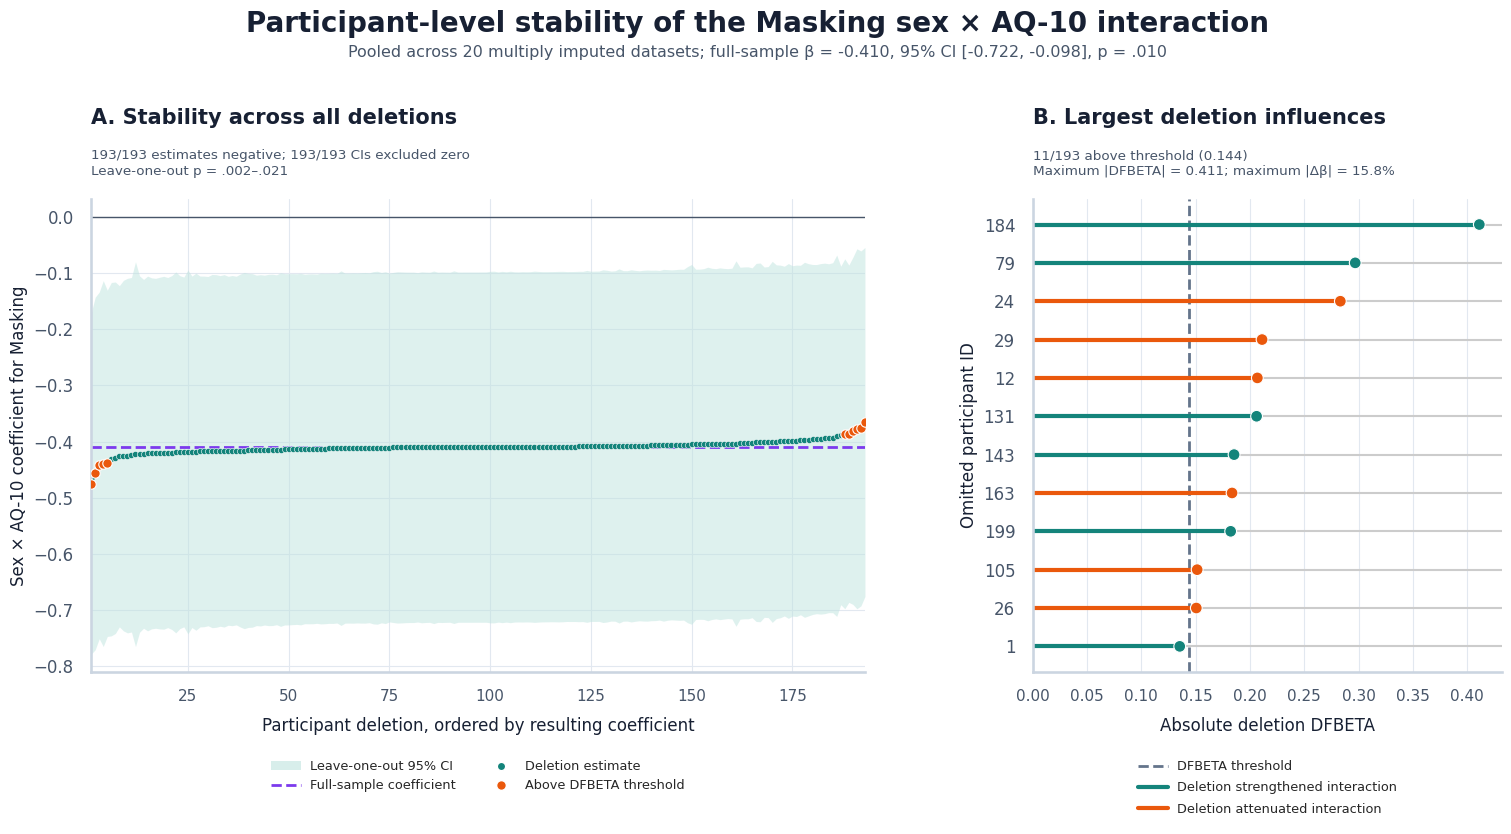


Saved results package: /content/Masking_interaction_MI_LOO_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ============================================================
# MASKING SEX × AQ-10 INTERACTION
# 20-IMPUTATION LEAVE-ONE-OUT STABILITY ANALYSIS + FIGURE
# ============================================================

from pathlib import Path
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D
from scipy import stats

try:
    from google.colab import files
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False


# ============================================================
# 1. SETTINGS
# ============================================================

EXPECTED_IMPUTATIONS = 20
TOP_INFLUENTIAL = 12
DOWNLOAD_RESULTS = True

OUTDIR = Path("Masking_interaction_MI_LOO_results")
OUTDIR.mkdir(exist_ok=True)


# ============================================================
# 2. LOCATE OR UPLOAD THE IMPUTATION PACKAGE
# ============================================================

zip_candidates = sorted(
    Path(".").glob(
        "UM_autism_hierarchy_imputation_package*.zip"
    ),
    key=lambda path: path.stat().st_mtime,
)

if zip_candidates:
    zip_path = zip_candidates[-1]
    print(f"Using: {zip_path.name}")

elif RUNNING_IN_COLAB:
    print(
        "Upload UM_autism_hierarchy_imputation_package.zip"
    )

    uploaded = files.upload()

    uploaded_zips = [
        Path(filename)
        for filename in uploaded
        if filename.lower().endswith(".zip")
    ]

    if not uploaded_zips:
        raise FileNotFoundError(
            "No ZIP file was uploaded."
        )

    zip_path = uploaded_zips[0]

else:
    raise FileNotFoundError(
        "Could not find the imputation package ZIP."
    )


# ============================================================
# 3. LOAD AND VALIDATE ALL COMPLETED DATASETS
# ============================================================

required_columns = {
    "ID",
    "sex",
    "age",
    "EQ",
    "SQ",
    "AQ10",
    "CAT-Q_mask",
}

with zipfile.ZipFile(zip_path) as archive:

    dataset_names = sorted(
        name
        for name in archive.namelist()
        if (
            "completed/"
            in name
            and "total_level_imputation_" in name
            and name.lower().endswith(".csv")
        )
    )

    if len(dataset_names) != EXPECTED_IMPUTATIONS:
        raise ValueError(
            f"Expected {EXPECTED_IMPUTATIONS} completed "
            f"datasets, but found {len(dataset_names)}."
        )

    datasets = [
        pd.read_csv(archive.open(name))
        for name in dataset_names
    ]


for number, data in enumerate(datasets, start=1):

    missing_columns = required_columns.difference(
        data.columns
    )

    if missing_columns:
        raise ValueError(
            f"Dataset {number} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    analytical = data[
        data["sex"].isin([0, 1])
    ]

    if analytical[list(required_columns)].isna().any().any():
        raise ValueError(
            f"Dataset {number} contains missing values "
            "in required analysis columns."
        )

    if analytical["ID"].duplicated().any():
        raise ValueError(
            f"Dataset {number} contains duplicate IDs."
        )


reference_ids = (
    datasets[0]
    .loc[datasets[0]["sex"].isin([0, 1]), "ID"]
    .tolist()
)

reference_id_set = set(reference_ids)

for number, data in enumerate(datasets[1:], start=2):

    current_ids = set(
        data.loc[
            data["sex"].isin([0, 1]),
            "ID",
        ]
    )

    if current_ids != reference_id_set:
        raise ValueError(
            f"Analytical IDs differ in dataset {number}."
        )


number_imputations = len(datasets)
number_participants = len(reference_ids)

print(
    f"Validated {number_imputations} completed datasets."
)

print(
    f"Analytical sample: N = {number_participants}."
)


# ============================================================
# 4. STANDARDIZATION AND HC3 MODEL
# ============================================================

def standardize(values):

    values = np.asarray(values, dtype=float)

    standard_deviation = values.std(ddof=0)

    if standard_deviation <= 0:
        raise ValueError(
            "Cannot standardize a constant variable."
        )

    return (
        values - values.mean()
    ) / standard_deviation


def fit_masking_interaction(
    data,
    omitted_id=None,
):

    analysis_data = (
        data.loc[data["sex"].isin([0, 1])]
        .copy()
    )

    if omitted_id is not None:

        analysis_data = analysis_data.loc[
            analysis_data["ID"] != omitted_id
        ].copy()

    sex = analysis_data["sex"].to_numpy(
        dtype=float
    )

    age = standardize(
        analysis_data["age"]
    )

    eq = standardize(
        analysis_data["EQ"]
    )

    sq = standardize(
        analysis_data["SQ"]
    )

    aq10 = standardize(
        analysis_data["AQ10"]
    )

    masking = standardize(
        analysis_data["CAT-Q_mask"]
    )

    # Model 3:
    # intercept + sex + age + EQ + SQ + AQ-10
    # + sex × EQ + sex × SQ + sex × AQ-10
    design_matrix = np.column_stack([
        np.ones(len(analysis_data)),
        sex,
        age,
        eq,
        sq,
        aq10,
        sex * eq,
        sex * sq,
        sex * aq10,
    ])

    number_parameters = design_matrix.shape[1]

    xtx_inverse = np.linalg.inv(
        design_matrix.T @ design_matrix
    )

    beta = (
        xtx_inverse
        @ design_matrix.T
        @ masking
    )

    residuals = (
        masking
        - design_matrix @ beta
    )

    leverage = np.sum(
        (design_matrix @ xtx_inverse)
        * design_matrix,
        axis=1,
    )

    # HC3 robust covariance matrix.
    hc3_residuals = (
        residuals / (1 - leverage)
    )

    weighted_design = (
        design_matrix
        * hc3_residuals[:, None]
    )

    meat = (
        weighted_design.T
        @ weighted_design
    )

    covariance = (
        xtx_inverse
        @ meat
        @ xtx_inverse
    )

    # Sex × AQ-10 is the final coefficient.
    target_index = 8

    return {
        "estimate": beta[target_index],
        "variance": covariance[
            target_index,
            target_index,
        ],
        "df_complete": (
            len(analysis_data)
            - number_parameters
        ),
    }


# ============================================================
# 5. RUBIN POOLING
# ============================================================

def pool_target_coefficient(completed_results):

    estimates = np.asarray(
        [
            result["estimate"]
            for result in completed_results
        ],
        dtype=float,
    )

    within_variances = np.asarray(
        [
            result["variance"]
            for result in completed_results
        ],
        dtype=float,
    )

    number_completed = len(completed_results)

    pooled_estimate = estimates.mean()

    within_variance = (
        within_variances.mean()
    )

    if number_completed > 1:

        between_variance = estimates.var(
            ddof=1
        )

    else:

        between_variance = 0.0

    total_variance = (
        within_variance
        + (1 + 1 / number_completed)
        * between_variance
    )

    standard_error = np.sqrt(
        total_variance
    )

    complete_df = completed_results[0][
        "df_complete"
    ]

    if (
        number_completed > 1
        and between_variance > 1e-15
    ):

        relative_increase = (
            (1 + 1 / number_completed)
            * between_variance
            / max(within_variance, 1e-15)
        )

        degrees_freedom = (
            (number_completed - 1)
            * (
                1
                + 1 / relative_increase
            ) ** 2
        )

        degrees_freedom = min(
            degrees_freedom,
            complete_df,
        )

    else:

        degrees_freedom = complete_df

    t_value = (
        pooled_estimate
        / standard_error
    )

    p_value = 2 * stats.t.sf(
        abs(t_value),
        degrees_freedom,
    )

    critical_value = stats.t.ppf(
        0.975,
        degrees_freedom,
    )

    return {
        "Beta": pooled_estimate,
        "SE": standard_error,
        "CI_low": (
            pooled_estimate
            - critical_value * standard_error
        ),
        "CI_high": (
            pooled_estimate
            + critical_value * standard_error
        ),
        "t": t_value,
        "df": degrees_freedom,
        "p": p_value,
    }


# ============================================================
# 6. FULL-SAMPLE POOLED RESULT
# ============================================================

full_completed_results = [
    fit_masking_interaction(data)
    for data in datasets
]

full_result = pool_target_coefficient(
    full_completed_results
)

print("\nFULL-SAMPLE POOLED RESULT")

print(
    f"β = {full_result['Beta']:.3f}, "
    f"SE = {full_result['SE']:.3f}, "
    f"95% CI "
    f"[{full_result['CI_low']:.3f}, "
    f"{full_result['CI_high']:.3f}], "
    f"p = {full_result['p']:.4f}"
)


# ============================================================
# 7. LEAVE ONE PARTICIPANT OUT
# ============================================================

loo_rows = []

for position, participant_id in enumerate(
    reference_ids,
    start=1,
):

    completed_results = [
        fit_masking_interaction(
            data,
            omitted_id=participant_id,
        )
        for data in datasets
    ]

    pooled_result = pool_target_coefficient(
        completed_results
    )

    loo_rows.append({
        "Omitted_ID": participant_id,
        **pooled_result,
    })

    if (
        position % 25 == 0
        or position == number_participants
    ):

        print(
            f"Completed {position}/"
            f"{number_participants} deletions"
        )


loo_results = pd.DataFrame(
    loo_rows
)


# ============================================================
# 8. DELETION DFBETA AND STABILITY STATISTICS
# ============================================================

loo_results["Delta_beta"] = (
    loo_results["Beta"]
    - full_result["Beta"]
)

loo_results["Deletion_DFBETA"] = (
    full_result["Beta"]
    - loo_results["Beta"]
) / full_result["SE"]

loo_results["Absolute_DFBETA"] = (
    loo_results["Deletion_DFBETA"].abs()
)

loo_results["Percent_change"] = (
    100
    * loo_results["Delta_beta"]
    / abs(full_result["Beta"])
)

loo_results["CI_excludes_zero"] = (
    (loo_results["CI_high"] < 0)
    | (loo_results["CI_low"] > 0)
)

dfbeta_threshold = (
    2 / np.sqrt(number_participants)
)

loo_results["Above_DFBETA_threshold"] = (
    loo_results["Absolute_DFBETA"]
    > dfbeta_threshold
)

number_negative = int(
    (loo_results["Beta"] < 0).sum()
)

number_ci_excludes_zero = int(
    loo_results["CI_excludes_zero"].sum()
)

number_flagged = int(
    loo_results[
        "Above_DFBETA_threshold"
    ].sum()
)

maximum_dfbeta = (
    loo_results["Absolute_DFBETA"].max()
)

maximum_change = (
    loo_results["Percent_change"]
    .abs()
    .max()
)


summary = pd.DataFrame([{
    "Number_imputations": number_imputations,
    "Analysis_N": number_participants,
    "Full_beta": full_result["Beta"],
    "Full_SE": full_result["SE"],
    "Full_CI_low": full_result["CI_low"],
    "Full_CI_high": full_result["CI_high"],
    "Full_p": full_result["p"],
    "LOO_beta_min": loo_results["Beta"].min(),
    "LOO_beta_max": loo_results["Beta"].max(),
    "LOO_p_min": loo_results["p"].min(),
    "LOO_p_max": loo_results["p"].max(),
    "Negative_estimates_N": number_negative,
    "CI_excludes_zero_N": (
        number_ci_excludes_zero
    ),
    "DFBETA_threshold": dfbeta_threshold,
    "N_above_DFBETA_threshold": (
        number_flagged
    ),
    "Maximum_absolute_DFBETA": (
        maximum_dfbeta
    ),
    "Maximum_absolute_percent_change": (
        maximum_change
    ),
}])


print("\nPOOLED LEAVE-ONE-OUT SUMMARY")

print(
    summary.round(4).to_string(index=False)
)


# ============================================================
# 9. PREPARE FIGURE DATA
# ============================================================

plot_data = (
    loo_results
    .sort_values("Beta")
    .reset_index(drop=True)
    .copy()
)

plot_data["Order"] = np.arange(
    1,
    len(plot_data) + 1,
)

flagged = (
    plot_data["Above_DFBETA_threshold"]
)

top_influential = (
    loo_results
    .nlargest(
        TOP_INFLUENTIAL,
        "Absolute_DFBETA",
    )
    .sort_values("Absolute_DFBETA")
    .copy()
)

top_influential["Strengthened"] = (
    top_influential["Beta"].abs()
    > abs(full_result["Beta"])
)


# ============================================================
# 10. VISUAL SETTINGS
# ============================================================

NAVY = "#172033"
SLATE = "#475569"
GRID = "#E2E8F0"

TEAL = "#14847B"
TEAL_LIGHT = "#BFE4DF"

ORANGE = "#EA580C"
PURPLE = "#7C3AED"
THRESHOLD_GREY = "#64748B"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.labelcolor": NAVY,
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "axes.edgecolor": "#CBD5E1",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def format_p(value):

    if value < 0.001:
        return "<.001"

    return f"{value:.3f}".replace(
        "0.",
        ".",
        1,
    )


# ============================================================
# 11. CREATE FIGURE WITH DEDICATED LEGEND ROWS
# ============================================================

figure = plt.figure(
    figsize=(15.5, 8.8)
)

grid = figure.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.65, 1],
    height_ratios=[1, 0.16],
    left=0.07,
    right=0.98,
    top=0.76,
    bottom=0.05,
    wspace=0.27,
    hspace=0.28,
)

ax_stability = figure.add_subplot(
    grid[0, 0]
)

ax_influence = figure.add_subplot(
    grid[0, 1]
)

legend_stability = figure.add_subplot(
    grid[1, 0]
)

legend_influence = figure.add_subplot(
    grid[1, 1]
)

legend_stability.axis("off")
legend_influence.axis("off")


# ============================================================
# 12. GLOBAL TITLE
# ============================================================

figure.suptitle(
    "Participant-level stability of the Masking "
    "sex × AQ-10 interaction",
    fontsize=20,
    fontweight="bold",
    color=NAVY,
    y=0.975,
)

figure.text(
    0.5,
    0.922,
    (
        f"Pooled across {number_imputations} multiply "
        f"imputed datasets; "
        f"full-sample β = {full_result['Beta']:.3f}, "
        f"95% CI [{full_result['CI_low']:.3f}, "
        f"{full_result['CI_high']:.3f}], "
        f"p = {format_p(full_result['p'])}"
    ),
    ha="center",
    fontsize=11.5,
    color=SLATE,
)


# ============================================================
# 13. PANEL A
# ============================================================

x_positions = (
    plot_data["Order"]
    .to_numpy(dtype=float)
)

ci_low = (
    plot_data["CI_low"]
    .to_numpy(dtype=float)
)

ci_high = (
    plot_data["CI_high"]
    .to_numpy(dtype=float)
)

beta_values = (
    plot_data["Beta"]
    .to_numpy(dtype=float)
)

ax_stability.fill_between(
    x_positions,
    ci_low,
    ci_high,
    color=TEAL_LIGHT,
    alpha=0.50,
    linewidth=0,
    zorder=1,
)

ax_stability.plot(
    x_positions,
    beta_values,
    color=TEAL,
    linewidth=2.2,
    zorder=2,
)

ax_stability.scatter(
    plot_data.loc[~flagged, "Order"],
    plot_data.loc[~flagged, "Beta"],
    s=20,
    color=TEAL,
    edgecolor="white",
    linewidth=0.4,
    zorder=3,
)

ax_stability.scatter(
    plot_data.loc[flagged, "Order"],
    plot_data.loc[flagged, "Beta"],
    s=46,
    color=ORANGE,
    edgecolor="white",
    linewidth=0.8,
    zorder=4,
)

ax_stability.axhline(
    full_result["Beta"],
    color=PURPLE,
    linestyle="--",
    linewidth=2,
    zorder=2,
)

ax_stability.axhline(
    0,
    color=SLATE,
    linewidth=1,
    zorder=1,
)

ax_stability.text(
    0,
    1.15,
    "A. Stability across all deletions",
    transform=ax_stability.transAxes,
    ha="left",
    va="bottom",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
    clip_on=False,
)

ax_stability.text(
    0,
    1.045,
    (
        f"{number_negative}/{number_participants} "
        f"estimates negative; "
        f"{number_ci_excludes_zero}/"
        f"{number_participants} CIs excluded zero\n"
        f"Leave-one-out p = "
        f"{format_p(loo_results['p'].min())}–"
        f"{format_p(loo_results['p'].max())}"
    ),
    transform=ax_stability.transAxes,
    ha="left",
    va="bottom",
    fontsize=9.7,
    color=SLATE,
    linespacing=1.25,
    clip_on=False,
)

ax_stability.set_xlabel(
    "Participant deletion, ordered by resulting coefficient",
    labelpad=9,
)

ax_stability.set_ylabel(
    "Sex × AQ-10 coefficient for Masking"
)

ax_stability.set_xlim(
    1,
    number_participants,
)

lower_limit = min(
    ci_low.min(),
    full_result["CI_low"],
)

vertical_padding = (
    0.04 * abs(lower_limit)
)

ax_stability.set_ylim(
    lower_limit - vertical_padding,
    vertical_padding,
)

ax_stability.grid(
    axis="both",
    color=GRID,
    linewidth=0.8,
    zorder=0,
)

ax_stability.spines["top"].set_visible(False)
ax_stability.spines["right"].set_visible(False)


# ============================================================
# 14. PANEL B
# ============================================================

y_positions = np.arange(
    len(top_influential)
)

absolute_dfbeta = (
    top_influential["Absolute_DFBETA"]
    .to_numpy(dtype=float)
)

influence_colors = np.where(
    top_influential["Strengthened"],
    TEAL,
    ORANGE,
)

ax_influence.hlines(
    y=y_positions,
    xmin=0,
    xmax=absolute_dfbeta,
    color=influence_colors,
    linewidth=3,
    zorder=2,
)

ax_influence.scatter(
    absolute_dfbeta,
    y_positions,
    color=influence_colors,
    s=72,
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
)

ax_influence.axvline(
    dfbeta_threshold,
    color=THRESHOLD_GREY,
    linestyle="--",
    linewidth=2,
    zorder=1,
)

ax_influence.text(
    0,
    1.15,
    "B. Largest deletion influences",
    transform=ax_influence.transAxes,
    ha="left",
    va="bottom",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
    clip_on=False,
)

ax_influence.text(
    0,
    1.045,
    (
        f"{number_flagged}/{number_participants} "
        f"above threshold ({dfbeta_threshold:.3f})\n"
        f"Maximum |DFBETA| = {maximum_dfbeta:.3f}; "
        f"maximum |Δβ| = {maximum_change:.1f}%"
    ),
    transform=ax_influence.transAxes,
    ha="left",
    va="bottom",
    fontsize=9.7,
    color=SLATE,
    linespacing=1.25,
    clip_on=False,
)

ax_influence.set_yticks(
    y_positions
)

ax_influence.set_yticklabels(
    top_influential["Omitted_ID"]
    .astype(str)
)

ax_influence.set_xlabel(
    "Absolute deletion DFBETA",
    labelpad=9,
)

ax_influence.set_ylabel(
    "Omitted participant ID"
)

ax_influence.set_xlim(
    0,
    max(
        absolute_dfbeta.max() * 1.05,
        dfbeta_threshold * 1.20,
    ),
)

ax_influence.margins(y=0.06)

ax_influence.grid(
    axis="x",
    color=GRID,
    linewidth=0.8,
    zorder=0,
)

ax_influence.spines["top"].set_visible(False)
ax_influence.spines["right"].set_visible(False)


# ============================================================
# 15. SEPARATE PANEL LEGENDS
# ============================================================

panel_a_handles = [
    mpatches.Patch(
        facecolor=TEAL_LIGHT,
        edgecolor="none",
        alpha=0.60,
        label="Leave-one-out 95% CI",
    ),
        Line2D(
        [0], [0],
        color=PURPLE,
        linestyle="--",
        linewidth=2,
        label="Full-sample coefficient",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=TEAL,
        markeredgecolor="white",
        markersize=6,
        label="Deletion estimate",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=ORANGE,
        markeredgecolor="white",
        markersize=7,
        label="Above DFBETA threshold",
    ),
]

panel_b_handles = [
    Line2D(
        [0], [0],
        color=THRESHOLD_GREY,
        linestyle="--",
        linewidth=2,
        label="DFBETA threshold",
    ),
    Line2D(
        [0], [0],
        color=TEAL,
        linewidth=3,
        label="Deletion strengthened interaction",
    ),
    Line2D(
        [0], [0],
        color=ORANGE,
        linewidth=3,
        label="Deletion attenuated interaction",
    ),
]

legend_stability.legend(
    handles=panel_a_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=9.3,
    handlelength=2.3,
    columnspacing=2.4,
    handletextpad=0.7,
)

legend_influence.legend(
    handles=panel_b_handles,
    loc="upper center",
    ncol=1,
    frameon=False,
    fontsize=9.3,
    handlelength=2.3,
    labelspacing=0.65,
    handletextpad=0.7,
)


# ============================================================
# 16. SAVE RESULTS
# ============================================================

summary_path = (
    OUTDIR
    / "Masking_interaction_MI_LOO_summary.csv"
)

deletions_path = (
    OUTDIR
    / "Masking_interaction_MI_LOO_all_deletions.csv"
)

png_path = (
    OUTDIR
    / "Figure_Masking_interaction_MI_LOO.png"
)

pdf_path = (
    OUTDIR
    / "Figure_Masking_interaction_MI_LOO.pdf"
)

summary.to_csv(
    summary_path,
    index=False,
)

loo_results.to_csv(
    deletions_path,
    index=False,
)

figure.savefig(
    png_path,
    dpi=350,
    bbox_inches="tight",
    facecolor="white",
)

figure.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ============================================================
# 17. PACKAGE OUTPUTS
# ============================================================

results_zip = Path(
    shutil.make_archive(
        "Masking_interaction_MI_LOO_results",
        "zip",
        root_dir=OUTDIR,
    )
)

print(f"\nSaved results package: {results_zip}")

if (
    RUNNING_IN_COLAB
    and DOWNLOAD_RESULTS
):
    files.download(str(results_zip))

# Model Results Figures

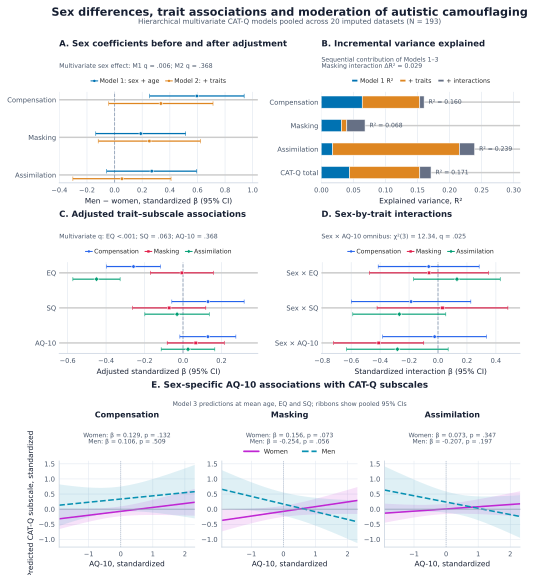

Saved: CATQ_additional_figure_results/Figure_CATQ_composite_A-E_SAGE.pdf/.eps/.tiff/.png


In [12]:
# ============================================================
# CAT-Q MANUSCRIPT COMPOSITE FIGURE
#
# Upload:
#   UM_autism_hierarchy_imputation_package.zip
# ============================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")  # sharp notebook preview
except ImportError:
    pass


# ------------------------------------------------------------
# 8. PALETTE AND TYPOGRAPHY
# ------------------------------------------------------------

INK = "#172033"
TEXT = "#475569"
GRID = "#E2E8F0"
ZERO = "#94A3B8"

# Quiet, color-blind-friendly model palette for A and B.
MODEL_1_COLOR = "#0072B2"   # baseline model
MODEL_2_COLOR = "#DE8621"   # trait-adjusted model
MODEL_3_COLOR = "#667085"   # interaction increment

# Same subscale mapping in C and D.
OUTCOME_COLORS = {
    "Compensation": "#2563EB",
    "Masking": "#E11D48",
    "Assimilation": "#009E73",
}
OUTCOME_MARKERS = {
    "Compensation": "o",
    "Masking": "s",
    "Assimilation": "D",
}

SEX_COLORS = {
    "Women": "#C026D3",
    "Men": "#0891B2",
}
SEX_LINESTYLES = {
    "Women": "-",
    "Men": "--",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7.0,
    "axes.labelsize": 7.4,
    "axes.labelcolor": INK,
    "xtick.labelsize": 6.6,
    "ytick.labelsize": 6.8,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "axes.edgecolor": "#CBD5E1",
    "axes.linewidth": 0.8,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "figure.dpi": 170,
})


# ------------------------------------------------------------
# 9. DATA FOR PANELS B AND D
# ------------------------------------------------------------

def mean_imputation_r2(model_name, outcome_column=None, total=False):
    """Mean R-squared across the 20 completed datasets."""
    values = []
    terms = MODEL_TERMS[model_name]

    for data in datasets:
        analysis_data = data.loc[data["sex"].isin([0, 1])].copy()
        X, _ = prepare_model_data(data, terms)

        if total:
            y_raw = analysis_data[OUTCOME_COLUMNS].sum(axis=1).to_numpy(float)
        else:
            y_raw = analysis_data[outcome_column].to_numpy(float)

        y = standardize(y_raw)
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        residual = y - X @ beta
        values.append(1 - np.sum(residual ** 2) / np.sum((y - y.mean()) ** 2))

    return float(np.mean(values))


r2_rows = []
for outcome, column in zip(OUTCOMES, OUTCOME_COLUMNS):
    row = {"Outcome": outcome}
    for model_name in ["Model 1", "Model 2", "Model 3"]:
        row[model_name] = mean_imputation_r2(model_name, outcome_column=column)
    r2_rows.append(row)

total_row = {"Outcome": "CAT-Q total"}
for model_name in ["Model 1", "Model 2", "Model 3"]:
    total_row[model_name] = mean_imputation_r2(model_name, total=True)
r2_rows.append(total_row)
panel_r2 = pd.DataFrame(r2_rows)


interaction_terms = {
    "Sex × EQ": "Sex_x_EQ",
    "Sex × SQ": "Sex_x_SQ",
    "Sex × AQ-10": "Sex_x_AQ10",
}
panel_interactions = pd.DataFrame([
    {
        "Interaction": interaction_label,
        "Outcome": outcome,
        **coefficient_result(
            pooled_models["Model 3"],
            MODEL_TERMS["Model 3"],
            outcome,
            term,
        ),
    }
    for interaction_label, term in interaction_terms.items()
    for outcome in OUTCOMES
])


# ------------------------------------------------------------
# 10. LAYOUT HELPERS
# ------------------------------------------------------------

def clean_axis(axis, xgrid=True):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)
    axis.tick_params(axis="y", length=0, pad=3)
    axis.tick_params(axis="x", length=2.5, pad=2)
    if xgrid:
        axis.grid(axis="x", color=GRID, linewidth=0.65, zorder=0)


def panel_axes(spec, title, subtitle, legend_handles, legend_ncol):
    """Separate header, legend, and plot axes prevent overlap."""
    inner = spec.subgridspec(
        3, 1,
        height_ratios=[0.23, 0.12, 0.65],
        hspace=0.05,
    )
    header = figure.add_subplot(inner[0])
    legend_axis = figure.add_subplot(inner[1])
    axis = figure.add_subplot(inner[2])

    header.axis("off")
    legend_axis.axis("off")
    header.text(
        0, 0.82, title,
        ha="left", va="center",
        fontsize=8.5, fontweight="bold", color=INK,
    )
    header.text(
        0, 0.04, subtitle,
        ha="left", va="bottom",
        fontsize=6.2, color=TEXT, linespacing=1.05,
    )
    legend_axis.legend(
      handles=legend_handles,
      loc="center",
      ncol=legend_ncol,
      frameon=False,
      fontsize=6.2,
      markerscale=1.0,
      handlelength=1.1,
      handleheight=0.45,
      handletextpad=0.3,
      columnspacing=1.0,
      borderaxespad=0,
  )
    return axis


LEGEND_MARKER_SIZE = 2.4

model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color=MODEL_1_COLOR,
        linewidth=1.0,
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=0,
        label="Model 1: sex + age",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color=MODEL_2_COLOR,
        linewidth=1.0,
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=0,
        label="Model 2: + traits",
    ),
]

subscale_handles = [
    Line2D(
        [0], [0],
        marker=OUTCOME_MARKERS[outcome],
        color=OUTCOME_COLORS[outcome],
        linewidth=1.0,
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=0,
        label=outcome,
    )
    for outcome in OUTCOMES
]
r2_handles = [
    Patch(facecolor=MODEL_1_COLOR, label="Model 1 R²"),
    Patch(facecolor=MODEL_2_COLOR, label="+ traits"),
    Patch(facecolor=MODEL_3_COLOR, label="+ interactions"),
]


# SAGE maximum full-page size: 7.125 × 8.125 inches.
figure = plt.figure(figsize=(7.125, 8.125))
outer = figure.add_gridspec(
    3, 1,
    height_ratios=[1.0, 1.0, 1.16],
    left=0.095,
    right=0.995,
    top=0.925,
    bottom=0.055,
    hspace=0.17,
)
top = outer[0].subgridspec(1, 2, wspace=0.32)
middle = outer[1].subgridspec(1, 2, wspace=0.32)

figure.suptitle(
    "Sex differences, trait associations and moderation of autistic camouflaging",
    x=0.545, y=0.978,
    fontsize=11.2, fontweight="bold", color=INK,
)
figure.text(
    0.545, 0.953,
    "Hierarchical multivariate CAT-Q models pooled across 20 imputed datasets (N = 193)",
    ha="center", va="center", fontsize=7.1, color=TEXT,
)


# ------------------------------------------------------------
# 11. PANEL A: SEX COEFFICIENTS
# ------------------------------------------------------------

ax_a = panel_axes(
    top[0],
    "A. Sex coefficients before and after adjustment",
    f"Multivariate sex effect: M1 q = {format_p(q_model_1_sex)}; M2 q = {format_p(q_model_2_sex)}",
    model_handles,
    2,
)

y_main = {"Compensation": 2, "Masking": 1, "Assimilation": 0}
model_offset = {"Model 1": 0.10, "Model 2": -0.10}
model_color = {"Model 1": MODEL_1_COLOR, "Model 2": MODEL_2_COLOR}

for model_name in ["Model 1", "Model 2"]:
    subset = panel_a.loc[panel_a["Model"] == model_name]
    y = np.array([y_main[o] + model_offset[model_name] for o in subset["Outcome"]])
    beta = subset["Beta"].to_numpy()
    ax_a.errorbar(
        beta, y,
        xerr=np.vstack([beta - subset["CI_low"].to_numpy(),
                        subset["CI_high"].to_numpy() - beta]),
        fmt="o", color=model_color[model_name], ecolor=model_color[model_name],
        markersize=3.5, markeredgecolor="white", markeredgewidth=0.55,
        elinewidth=1.25, capsize=2.2, zorder=3,
    )

ax_a.axvline(0, color=ZERO, linestyle="--", linewidth=0.9)
ax_a.set_yticks([2, 1, 0], OUTCOMES)
ax_a.set_xlabel("Men − women, standardized β (95% CI)", labelpad=4)
a_lo, a_hi = min(panel_a["CI_low"].min(), 0), max(panel_a["CI_high"].max(), 0)
ax_a.set_xlim(a_lo - 0.08 * (a_hi - a_lo), a_hi + 0.08 * (a_hi - a_lo))
clean_axis(ax_a)


# ------------------------------------------------------------
# 12. PANEL B: INCREMENTAL VARIANCE
# ------------------------------------------------------------

mask_r2 = panel_r2.set_index("Outcome").loc["Masking"]
ax_b = panel_axes(
    top[1],
    "B. Incremental variance explained",
    "Sequential contribution of Models 1–3\n"
    f"Masking interaction ΔR² = {mask_r2['Model 3'] - mask_r2['Model 2']:.3f}",
    r2_handles,
    3,
)

y = np.arange(len(panel_r2))[::-1]
r2_1 = panel_r2["Model 1"].to_numpy()
r2_2 = panel_r2["Model 2"].to_numpy()
r2_3 = panel_r2["Model 3"].to_numpy()
ax_b.barh(y, r2_1, height=0.52, color=MODEL_1_COLOR,
          edgecolor="white", linewidth=0.55, zorder=2)
ax_b.barh(y, r2_2 - r2_1, left=r2_1, height=0.52, color=MODEL_2_COLOR,
          edgecolor="white", linewidth=0.55, zorder=2)
ax_b.barh(y, r2_3 - r2_2, left=r2_2, height=0.52, color=MODEL_3_COLOR,
          edgecolor="white", linewidth=0.55, zorder=2)

for yi, value in zip(y, r2_3):
    ax_b.text(value + 0.007, yi, f"R² = {value:.3f}",
              va="center", fontsize=6.1, color=TEXT)

ax_b.set_yticks(y, panel_r2["Outcome"])
ax_b.set_xlabel("Explained variance, R²", labelpad=4)
ax_b.set_xlim(0, max(0.31, r2_3.max() + 0.06))
clean_axis(ax_b)


# ------------------------------------------------------------
# 13. PANEL C: ADJUSTED TRAIT ASSOCIATIONS
# ------------------------------------------------------------

ax_c = panel_axes(
    middle[0],
    "C. Adjusted trait–subscale associations",
    f"Multivariate q: EQ {format_p(q_model_2_eq)}; SQ = {format_p(q_model_2_sq)}; AQ-10 = {format_p(q_model_2_aq10)}",
    subscale_handles,
    3,
)

trait_y = {"EQ": 2, "SQ": 1, "AQ-10": 0}
outcome_offset = {"Compensation": 0.18, "Masking": 0, "Assimilation": -0.18}
for outcome in OUTCOMES:
    subset = panel_b.loc[panel_b["Outcome"] == outcome]
    yy = np.array([trait_y[t] + outcome_offset[outcome] for t in subset["Trait"]])
    beta = subset["Beta"].to_numpy()
    ax_c.errorbar(
        beta, yy,
        xerr=np.vstack([beta - subset["CI_low"].to_numpy(),
                        subset["CI_high"].to_numpy() - beta]),
        fmt=OUTCOME_MARKERS[outcome],
        color=OUTCOME_COLORS[outcome], ecolor=OUTCOME_COLORS[outcome],
        markersize=3.5, markeredgecolor="white", markeredgewidth=0.55,
        elinewidth=1.15, capsize=2.0, zorder=3,
    )

ax_c.axvline(0, color=ZERO, linestyle="--", linewidth=0.9)
ax_c.set_yticks([2, 1, 0], ["EQ", "SQ", "AQ-10"])
ax_c.set_xlabel("Adjusted standardized β (95% CI)", labelpad=4)
c_lo, c_hi = min(panel_b["CI_low"].min(), 0), max(panel_b["CI_high"].max(), 0)
ax_c.set_xlim(c_lo - 0.08 * (c_hi - c_lo), c_hi + 0.08 * (c_hi - c_lo))
clean_axis(ax_c)


# ------------------------------------------------------------
# 14. PANEL D: INTERACTIONS
# ------------------------------------------------------------

ax_d = panel_axes(
    middle[1],
    "D. Sex-by-trait interactions",
    f"Sex × AQ-10 omnibus: χ²({aq10_interaction_test['df']}) = {aq10_interaction_test['Wald']:.2f}, q = {format_p(q_model_3_aq10_interaction)}",
    subscale_handles,
    3,
)

interaction_y = {"Sex × EQ": 2, "Sex × SQ": 1, "Sex × AQ-10": 0}
for outcome in OUTCOMES:
    subset = panel_interactions.loc[panel_interactions["Outcome"] == outcome]
    yy = np.array([interaction_y[t] + outcome_offset[outcome]
                   for t in subset["Interaction"]])
    beta = subset["Beta"].to_numpy()
    ax_d.errorbar(
        beta, yy,
        xerr=np.vstack([beta - subset["CI_low"].to_numpy(),
                        subset["CI_high"].to_numpy() - beta]),
        fmt=OUTCOME_MARKERS[outcome],
        color=OUTCOME_COLORS[outcome], ecolor=OUTCOME_COLORS[outcome],
        markersize=3.5,
        markeredgecolor="white", markeredgewidth=0.55,  # no special dark border
        elinewidth=1.15, capsize=2.0, zorder=3,
    )

ax_d.axvline(0, color=ZERO, linestyle="--", linewidth=0.9)
ax_d.set_yticks([2, 1, 0], ["Sex × EQ", "Sex × SQ", "Sex × AQ-10"])
ax_d.set_xlabel("Standardized interaction β (95% CI)", labelpad=4)
d_lo = min(panel_interactions["CI_low"].min(), 0)
d_hi = max(panel_interactions["CI_high"].max(), 0)
ax_d.set_xlim(d_lo - 0.07 * (d_hi - d_lo), d_hi + 0.07 * (d_hi - d_lo))
clean_axis(ax_d)


# ------------------------------------------------------------
# 15. PANEL E: ALL THREE SEX-SPECIFIC PREDICTION FIGURES
# ------------------------------------------------------------

bottom = outer[2].subgridspec(
    4, 3,
    height_ratios=[0.17, 0.21, 0.08, 0.54],
    hspace=0.07,
    wspace=0.20,
)
e_header = figure.add_subplot(bottom[0, :])
e_header.axis("off")
e_header.text(
    0.5, 0.78,
    "E. Sex-specific AQ-10 associations with CAT-Q subscales",
    ha="center", va="center", fontsize=8.8, fontweight="bold", color=INK,
)
e_header.text(
    0.5, 0.08,
    "Model 3 predictions at mean age, EQ and SQ; ribbons show pooled 95% CIs",
    ha="center", va="center", fontsize=6.2, color=TEXT,
)

prediction_axes = []
all_prediction_limits = []
for outcome in OUTCOMES:
    for sex_label in ["Women", "Men"]:
        all_prediction_limits.extend([
            prediction_results[outcome][sex_label]["CI_low"].min(),
            prediction_results[outcome][sex_label]["CI_high"].max(),
        ])
e_ymin = min(min(all_prediction_limits), 0)
e_ymax = max(max(all_prediction_limits), 0)
e_pad = 0.05 * (e_ymax - e_ymin)

for col, outcome in enumerate(OUTCOMES):
    title_axis = figure.add_subplot(bottom[1, col])
    axis = figure.add_subplot(bottom[3, col])
    title_axis.axis("off")
    prediction_axes.append(axis)

    women = simple_slopes.loc[(simple_slopes["Outcome"] == outcome) &
                              (simple_slopes["Sex"] == "Women")].iloc[0]
    men = simple_slopes.loc[(simple_slopes["Outcome"] == outcome) &
                            (simple_slopes["Sex"] == "Men")].iloc[0]

    title_axis.text(0.5, 0.82, outcome, ha="center", va="center",
                    fontsize=8.0, fontweight="bold", color=INK)
    title_axis.text(
        0.5, 0.12,
        f"Women: β = {women['Estimate']:.3f}, p = {format_p(women['p'])}\n"
        f"Men: β = {men['Estimate']:.3f}, p = {format_p(men['p'])}",
        ha="center", va="center", fontsize=6.1, color=TEXT, linespacing=1.05,
    )

    for sex_label in ["Women", "Men"]:
        result = prediction_results[outcome][sex_label]
        color = SEX_COLORS[sex_label]
        axis.fill_between(
            prediction_x, result["CI_low"], result["CI_high"],
            color=color, alpha=0.13, linewidth=0,
        )
        axis.plot(
            prediction_x, result["Estimate"],
            color=color, linestyle=SEX_LINESTYLES[sex_label], linewidth=1.55,
        )

    axis.axhline(0, color=ZERO, linewidth=0.75)
    axis.axvline(0, color=ZERO, linestyle=":", linewidth=0.75)
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(e_ymin - e_pad, e_ymax + e_pad)
    axis.set_xlabel("AQ-10, standardized", labelpad=3)
    axis.grid(color=GRID, linewidth=0.55)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.tick_params(length=2.2, pad=2)

prediction_axes[0].set_ylabel("Predicted CAT-Q subscale, standardized", labelpad=4)
for axis in prediction_axes[1:]:
    axis.set_ylabel("")

e_legend = figure.add_subplot(bottom[2, :])
e_legend.axis("off")
e_legend.legend(
    handles=[
        Line2D([0], [0], color=SEX_COLORS["Women"], linewidth=1.8,
               linestyle=SEX_LINESTYLES["Women"], label="Women"),
        Line2D([0], [0], color=SEX_COLORS["Men"], linewidth=1.8,
               linestyle=SEX_LINESTYLES["Men"], label="Men"),
    ],
    loc="center", ncol=2, frameon=False, fontsize=6.4,
    handlelength=2.3, columnspacing=2.2, borderaxespad=0,
)


# ------------------------------------------------------------
# 16. SAVE AT EXACT SAGE DIMENSIONS
# ------------------------------------------------------------

OUTDIR.mkdir(exist_ok=True)
base = OUTDIR / "Figure_CATQ_composite_A-E_SAGE"

panel_r2.to_csv(OUTDIR / "Figure_panel_B_R2_data.csv", index=False)
panel_interactions.to_csv(OUTDIR / "Figure_panel_D_interaction_data.csv", index=False)

# Do not use bbox_inches='tight': it changes the physical dimensions.
figure.savefig(base.with_suffix(".pdf"))
figure.savefig(base.with_suffix(".eps"), format="eps")
figure.savefig(base.with_suffix(".tiff"), dpi=800,
               pil_kwargs={"compression": "tiff_lzw"})
figure.savefig(base.with_suffix(".png"), dpi=600)

plt.show()
print(f"Saved: {base}.pdf/.eps/.tiff/.png")

# Model Results Tables

In [13]:
# ============================================================
# CAT-Q MANUSCRIPT TABLES
#
# Upload:
#   UM_autism_hierarchy_imputation_package.zip
#
# Produces:
#   CATQ_main_tables.docx
#   CATQ_main_tables.xlsx
#   Individual CSV tables
#   CATQ_main_tables_package.zip
# ============================================================

import sys, subprocess, warnings, zipfile, shutil, itertools
from pathlib import Path

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "python-docx", "openpyxl"
])

import numpy as np
import pandas as pd
from scipy.stats import chi2, t as t_dist
from google.colab import files
from IPython.display import display

from docx import Document
from docx.enum.section import WD_ORIENT
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.shared import Inches, Pt, RGBColor
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

from openpyxl import Workbook
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter


# ============================================================
# 1. UPLOAD AND EXTRACT DATA
# ============================================================

print("Upload UM_autism_hierarchy_imputation_package.zip")
uploaded = files.upload()

workdir = Path("/content/CATQ_table_builder")
if workdir.exists():
    shutil.rmtree(workdir)

input_dir = workdir / "input"
output_dir = workdir / "output"
input_dir.mkdir(parents=True)
output_dir.mkdir(parents=True)


def safe_extract(zf, destination):
    """Prevent ZIP path traversal."""
    destination = destination.resolve()

    for member in zf.infolist():
        target = (destination / member.filename).resolve()

        if destination not in target.parents and target != destination:
            raise ValueError(f"Unsafe ZIP path: {member.filename}")

    zf.extractall(destination)


for filename, content in uploaded.items():
    path = input_dir / Path(filename).name
    path.write_bytes(content)

    if zipfile.is_zipfile(path):
        extract_dir = input_dir / f"{path.stem}_extracted"
        extract_dir.mkdir(exist_ok=True)

        with zipfile.ZipFile(path) as zf:
            safe_extract(zf, extract_dir)


# ============================================================
# 2. FIND AND VALIDATE IMPUTED DATASETS
# ============================================================

required_columns = [
    "ID", "sex", "age", "EQ", "SQ", "AQ10",
    "CAT-Q", "CAT-Q_comp", "CAT-Q_mask", "CAT-Q_assim"
]

csv_paths = sorted(input_dir.rglob("*.csv"))
datasets = []
dataset_names = []

for path in csv_paths:
    try:
        df = pd.read_csv(path)
    except Exception:
        continue

    if not set(required_columns).issubset(df.columns):
        continue

    df = df.copy()

    for column in required_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    if df[required_columns].isna().any().any():
        print(f"Skipping incomplete dataset: {path.name}")
        continue

    df = df.sort_values("ID").reset_index(drop=True)
    datasets.append(df)
    dataset_names.append(path.name)

if not datasets:
    raise ValueError(
        "No valid completed datasets were found. Upload the hierarchy-imputation ZIP."
    )

# Confirm that all imputations contain the same participants.
reference_ids = datasets[0]["ID"].tolist()

for name, df in zip(dataset_names, datasets):
    if df["ID"].tolist() != reference_ids:
        raise ValueError(f"Participant IDs differ in {name}.")

print(f"\nValidated {len(datasets)} completed dataset(s).")

if len(datasets) == 1:
    warnings.warn(
        "Only one dataset was detected. Tables will be produced, but "
        "between-imputation uncertainty cannot be estimated."
    )
else:
    print("Coefficients and covariance matrices will be pooled using Rubin's rules.")


# Retain women and men for inferential models.
analysis_datasets = []

for df in datasets:
    d = df[df["sex"].isin([0, 1])].copy()
    d = d.sort_values("ID").reset_index(drop=True)
    analysis_datasets.append(d)

N = len(analysis_datasets[0])
n_women = int((analysis_datasets[0]["sex"] == 0).sum())
n_men = int((analysis_datasets[0]["sex"] == 1).sum())
n_excluded = len(datasets[0]) - N

print(
    f"Analytical sample: N = {N}; "
    f"{n_women} women and {n_men} men."
)

if n_excluded:
    print(
        f"Excluded from binary women–men models: "
        f"{n_excluded} participant(s) in another sex/gender category."
    )


# ============================================================
# 3. STANDARDIZE VARIABLES WITHIN EACH IMPUTATION
# ============================================================

outcomes = [
    "CAT-Q_comp",
    "CAT-Q_mask",
    "CAT-Q_assim"
]

outcome_labels = {
    "CAT-Q_comp": "Compensation",
    "CAT-Q_mask": "Masking",
    "CAT-Q_assim": "Assimilation",
    "CAT-Q": "CAT-Q total"
}

continuous_variables = [
    "age", "EQ", "SQ", "AQ10",
    "CAT-Q", "CAT-Q_comp", "CAT-Q_mask", "CAT-Q_assim"
]

standardized_datasets = []

for df in analysis_datasets:
    z = df.copy()

    for column in continuous_variables:
        sd = z[column].std(ddof=1)

        if not np.isfinite(sd) or sd == 0:
            raise ValueError(f"{column} has zero or invalid variance.")

        z[column] = (z[column] - z[column].mean()) / sd

    z["Sex_x_EQ"] = z["sex"] * z["EQ"]
    z["Sex_x_SQ"] = z["sex"] * z["SQ"]
    z["Sex_x_AQ10"] = z["sex"] * z["AQ10"]

    standardized_datasets.append(z)


# ============================================================
# 4. MODEL DEFINITIONS
# ============================================================

term_columns = {
    "Sex": "sex",
    "Age": "age",
    "EQ": "EQ",
    "SQ": "SQ",
    "AQ10": "AQ10",
    "Sex_x_EQ": "Sex_x_EQ",
    "Sex_x_SQ": "Sex_x_SQ",
    "Sex_x_AQ10": "Sex_x_AQ10"
}

term_labels = {
    "Sex": "Men vs women",
    "Age": "Age",
    "EQ": "EQ",
    "SQ": "SQ",
    "AQ10": "AQ-10",
    "Sex_x_EQ": "Sex × EQ",
    "Sex_x_SQ": "Sex × SQ",
    "Sex_x_AQ10": "Sex × AQ-10"
}

model_terms = {
    "Model 1: sex + age": [
        "Intercept", "Sex", "Age"
    ],
    "Model 2: + EQ, SQ, AQ-10": [
        "Intercept", "Sex", "Age", "EQ", "SQ", "AQ10"
    ],
    "Model 3: + sex interactions": [
        "Intercept", "Sex", "Age", "EQ", "SQ", "AQ10",
        "Sex_x_EQ", "Sex_x_SQ", "Sex_x_AQ10"
    ]
}


def make_design_matrix(df, terms):
    columns = []

    for term in terms:
        if term == "Intercept":
            columns.append(np.ones(len(df)))
        else:
            columns.append(
                df[term_columns[term]].to_numpy(dtype=float)
            )

    return np.column_stack(columns)


# ============================================================
# 5. MULTIVARIATE OLS WITH CROSS-OUTCOME HC3 COVARIANCE
# ============================================================

def fit_multivariate(df, terms, outcome_names):
    """
    Fits outcomes using a common design matrix.

    Coefficient vector ordering:
        outcome 1: all terms
        outcome 2: all terms
        ...
    """

    X = make_design_matrix(df, terms)
    Y = df[outcome_names].to_numpy(dtype=float)

    n, p = X.shape
    q = Y.shape[1]

    xtx_inv = np.linalg.pinv(X.T @ X)
    coefficients = xtx_inv @ X.T @ Y
    residuals = Y - X @ coefficients

    leverage = np.einsum(
        "ij,jk,ik->i",
        X, xtx_inv, X
    )

    hc3_adjustment = 1.0 / np.clip(
        (1.0 - leverage) ** 2,
        1e-12,
        None
    )

    covariance = np.zeros((p * q, p * q))

    for j in range(q):
        for k in range(q):
            weights = (
                residuals[:, j]
                * residuals[:, k]
                * hc3_adjustment
            )

            meat = X.T @ (X * weights[:, None])
            block = xtx_inv @ meat @ xtx_inv

            covariance[
                j * p:(j + 1) * p,
                k * p:(k + 1) * p
            ] = block

    theta = coefficients.T.reshape(-1)

    sse = np.sum(residuals ** 2, axis=0)
    centered = Y - Y.mean(axis=0)
    sst = np.sum(centered ** 2, axis=0)
    r_squared = 1.0 - (sse / sst)

    return {
        "theta": theta,
        "covariance": covariance,
        "r_squared": r_squared,
        "terms": terms,
        "outcomes": outcome_names,
        "n": n,
        "p": p,
        "q": q
    }


def pool_fits(fits):
    """Rubin pooling for coefficient vectors and covariance matrices."""

    estimates = np.vstack([fit["theta"] for fit in fits])
    within_covariances = np.stack(
        [fit["covariance"] for fit in fits]
    )

    m = len(fits)
    pooled_estimate = estimates.mean(axis=0)
    mean_within = within_covariances.mean(axis=0)

    if m > 1:
        between = np.cov(
            estimates,
            rowvar=False,
            ddof=1
        )

        if np.ndim(between) == 0:
            between = np.array([[between]])
    else:
        between = np.zeros_like(mean_within)

    total_covariance = (
        mean_within
        + (1.0 + 1.0 / m) * between
    )

    return {
        "theta": pooled_estimate,
        "covariance": total_covariance,
        "within": mean_within,
        "between": between,
        "fits": fits,
        "terms": fits[0]["terms"],
        "outcomes": fits[0]["outcomes"],
        "n": fits[0]["n"],
        "p": fits[0]["p"],
        "q": fits[0]["q"]
    }


multivariate_results = {}
total_results = {}

for model_name, terms in model_terms.items():
    mv_fits = [
        fit_multivariate(df, terms, outcomes)
        for df in standardized_datasets
    ]

    total_fits = [
        fit_multivariate(df, terms, ["CAT-Q"])
        for df in standardized_datasets
    ]

    multivariate_results[model_name] = pool_fits(mv_fits)
    total_results[model_name] = pool_fits(total_fits)


# ============================================================
# 6. STATISTICAL UTILITIES
# ============================================================

def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p_values), np.nan)

    valid = np.isfinite(p_values)

    if not valid.any():
        return adjusted

    p = p_values[valid]
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]

    q_ranked = ranked * m / np.arange(1, m + 1)
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0, 1)

    q = np.empty(m)
    q[order] = q_ranked
    adjusted[valid] = q

    return adjusted


def significance(q):
    if q < .001:
        return "***"
    if q < .01:
        return "**"
    if q < .05:
        return "*"
    return ""


def format_p(value):
    if not np.isfinite(value):
        return ""

    if value < .001:
        return "<.001"

    return f"{value:.3f}".lstrip("0")


def format_number(value, decimals=3):
    if not np.isfinite(value):
        return ""

    return f"{value:.{decimals}f}"


def format_ci(low, high):
    return f"[{low:.3f}, {high:.3f}]"


def coefficient_index(result, outcome, term):
    outcome_index = result["outcomes"].index(outcome)
    term_index = result["terms"].index(term)
    return outcome_index * result["p"] + term_index


def wald_test(result, outcome_term_pairs):
    indices = [
        coefficient_index(result, outcome, term)
        for outcome, term in outcome_term_pairs
    ]

    estimate = result["theta"][indices]
    covariance = result["covariance"][np.ix_(indices, indices)]
    covariance_inverse = np.linalg.pinv(covariance)

    statistic = float(
        estimate.T @ covariance_inverse @ estimate
    )

    df = int(np.linalg.matrix_rank(covariance))
    p_value = float(chi2.sf(statistic, df))

    return statistic, df, p_value


def coefficient_table(result, analysis_label):
    rows = []
    residual_df = result["n"] - result["p"]
    critical = t_dist.ppf(.975, residual_df)

    for outcome in result["outcomes"]:
        for term in result["terms"]:
            if term == "Intercept":
                continue

            index = coefficient_index(result, outcome, term)
            beta = result["theta"][index]
            se = np.sqrt(
                max(result["covariance"][index, index], 0)
            )

            t_value = beta / se
            p_value = 2 * t_dist.sf(
                abs(t_value),
                residual_df
            )

            rows.append({
                "Analysis": analysis_label,
                "Outcome": outcome_labels[outcome],
                "Term_key": term,
                "Predictor": term_labels[term],
                "Standardized beta": beta,
                "SE": se,
                "CI_low": beta - critical * se,
                "CI_high": beta + critical * se,
                "t": t_value,
                "df": residual_df,
                "p": p_value
            })

    table = pd.DataFrame(rows)

    # FDR across all non-intercept coefficients in this model.
    table["q"] = benjamini_hochberg(table["p"].to_numpy())
    table["Significance"] = table["q"].map(significance)

    return table


all_coefficient_tables = []

for model_name in model_terms:
    mv_coef = coefficient_table(
        multivariate_results[model_name],
        f"{model_name} — CAT-Q subscales"
    )

    total_coef = coefficient_table(
        total_results[model_name],
        f"{model_name} — CAT-Q total"
    )

    all_coefficient_tables.extend([mv_coef, total_coef])

full_coefficients = pd.concat(
    all_coefficient_tables,
    ignore_index=True
)


# ============================================================
# 7. TABLE 1 — DESCRIPTIVE STATISTICS
# ============================================================

descriptive_variables = [
    ("Age, years", "age"),
    ("Empathy Quotient (EQ)", "EQ"),
    ("Systemizing Quotient (SQ)", "SQ"),
    ("AQ-10", "AQ10"),
    ("CAT-Q total", "CAT-Q"),
    ("Compensation", "CAT-Q_comp"),
    ("Masking", "CAT-Q_mask"),
    ("Assimilation", "CAT-Q_assim")
]


def pooled_description(variable, group=None):
    means = []
    sds = []

    for df in analysis_datasets:
        sample = df if group is None else df[df["sex"] == group]
        means.append(sample[variable].mean())
        sds.append(sample[variable].std(ddof=1))

    return np.mean(means), np.mean(sds)


table1_rows = [{
    "Variable": "N",
    "Overall": str(N),
    "Women": str(n_women),
    "Men": str(n_men)
}]

for label, variable in descriptive_variables:
    overall_mean, overall_sd = pooled_description(variable)
    women_mean, women_sd = pooled_description(variable, 0)
    men_mean, men_sd = pooled_description(variable, 1)

    table1_rows.append({
        "Variable": label,
        "Overall": f"{overall_mean:.2f} ({overall_sd:.2f})",
        "Women": f"{women_mean:.2f} ({women_sd:.2f})",
        "Men": f"{men_mean:.2f} ({men_sd:.2f})"
    })

table1 = pd.DataFrame(table1_rows)


# ============================================================
# 8. TABLE 2 — MULTIVARIATE MODEL SEQUENCE
# ============================================================

table2_specification = {
    "Model 1: sex + age": [
        ("Men vs women", ["Sex"]),
        ("Age", ["Age"])
    ],
    "Model 2: + EQ, SQ, AQ-10": [
        ("Men vs women", ["Sex"]),
        ("Age", ["Age"]),
        ("EQ", ["EQ"]),
        ("SQ", ["SQ"]),
        ("AQ-10", ["AQ10"]),
        ("EQ, SQ, and AQ-10 jointly", ["EQ", "SQ", "AQ10"])
    ],
    "Model 3: + sex interactions": [
        ("Sex × EQ", ["Sex_x_EQ"]),
        ("Sex × SQ", ["Sex_x_SQ"]),
        ("Sex × AQ-10", ["Sex_x_AQ10"]),
        (
            "All sex interactions jointly",
            ["Sex_x_EQ", "Sex_x_SQ", "Sex_x_AQ10"]
        )
    ]
}

table2_parts = []

for model_name, effects in table2_specification.items():
    result = multivariate_results[model_name]
    rows = []

    for effect_label, terms in effects:
        pairs = [
            (outcome, term)
            for term in terms
            for outcome in outcomes
        ]

        statistic, df, p_value = wald_test(result, pairs)

        rows.append({
            "Model": model_name,
            "Effect": effect_label,
            "Wald chi-square": statistic,
            "df": df,
            "p": p_value
        })

    part = pd.DataFrame(rows)
    part["q"] = benjamini_hochberg(part["p"].to_numpy())
    part["Significance"] = part["q"].map(significance)
    table2_parts.append(part)

table2 = pd.concat(table2_parts, ignore_index=True)


# ============================================================
# 9. TABLE 3A — SEX EFFECTS ACROSS MODEL STAGES
# ============================================================

def select_coefficient(model_name, outcome_label, term_key, total=False):
    analysis_name = (
        f"{model_name} — CAT-Q total"
        if total
        else f"{model_name} — CAT-Q subscales"
    )

    selected = full_coefficients[
        (full_coefficients["Analysis"] == analysis_name)
        & (full_coefficients["Outcome"] == outcome_label)
        & (full_coefficients["Term_key"] == term_key)
    ]

    if len(selected) != 1:
        raise ValueError(
            f"Could not uniquely find {model_name}, "
            f"{outcome_label}, {term_key}"
        )

    return selected.iloc[0]


table3a_rows = []

for model_name in [
    "Model 1: sex + age",
    "Model 2: + EQ, SQ, AQ-10"
]:
    for outcome in outcomes:
        label = outcome_labels[outcome]
        row = select_coefficient(
            model_name, label, "Sex", total=False
        )

        table3a_rows.append({
            "Outcome": label,
            "Model": model_name,
            "Standardized beta": row["Standardized beta"],
            "95% CI": format_ci(row["CI_low"], row["CI_high"]),
            "p": row["p"],
            "q": row["q"],
            "Significance": row["Significance"]
        })

    row = select_coefficient(
        model_name, "CAT-Q total", "Sex", total=True
    )

    table3a_rows.append({
        "Outcome": "CAT-Q total",
        "Model": model_name,
        "Standardized beta": row["Standardized beta"],
        "95% CI": format_ci(row["CI_low"], row["CI_high"]),
        "p": row["p"],
        "q": row["q"],
        "Significance": row["Significance"]
    })

table3a = pd.DataFrame(table3a_rows)


# ============================================================
# 10. TABLE 3B — MODEL 2 TRAIT ASSOCIATIONS
# ============================================================

table3b_rows = []
model2_name = "Model 2: + EQ, SQ, AQ-10"

for term in ["EQ", "SQ", "AQ10"]:
    for outcome in outcomes:
        label = outcome_labels[outcome]
        row = select_coefficient(
            model2_name, label, term, total=False
        )

        table3b_rows.append({
            "Outcome": label,
            "Predictor": term_labels[term],
            "Standardized beta": row["Standardized beta"],
            "95% CI": format_ci(row["CI_low"], row["CI_high"]),
            "p": row["p"],
            "q": row["q"],
            "Significance": row["Significance"]
        })

    row = select_coefficient(
        model2_name, "CAT-Q total", term, total=True
    )

    table3b_rows.append({
        "Outcome": "CAT-Q total",
        "Predictor": term_labels[term],
        "Standardized beta": row["Standardized beta"],
        "95% CI": format_ci(row["CI_low"], row["CI_high"]),
        "p": row["p"],
        "q": row["q"],
        "Significance": row["Significance"]
    })

table3b = pd.DataFrame(table3b_rows)


# ============================================================
# 11. TABLE 3C — R-SQUARED AND SHAPLEY CONTRIBUTIONS
# ============================================================

baseline_terms = ["Intercept", "Sex", "Age"]
shapley_predictors = ["EQ", "SQ", "AQ10"]


def calculate_r_squared(df, terms, outcome):
    fit = fit_multivariate(df, terms, [outcome])
    return float(fit["r_squared"][0])


def shapley_for_dataset(df, outcome):
    contributions = {
        predictor: 0.0
        for predictor in shapley_predictors
    }

    permutations = list(
        itertools.permutations(shapley_predictors)
    )

    for order in permutations:
        current_terms = baseline_terms.copy()
        previous_r2 = calculate_r_squared(
            df, current_terms, outcome
        )

        for predictor in order:
            current_terms = current_terms + [predictor]
            new_r2 = calculate_r_squared(
                df, current_terms, outcome
            )

            contributions[predictor] += (
                new_r2 - previous_r2
            )

            previous_r2 = new_r2

    for predictor in contributions:
        contributions[predictor] /= len(permutations)

    return contributions


all_table_outcomes = outcomes + ["CAT-Q"]
shapley_results = {}

for outcome in all_table_outcomes:
    per_imputation = [
        shapley_for_dataset(df, outcome)
        for df in standardized_datasets
    ]

    shapley_results[outcome] = {
        predictor: np.mean([
            result[predictor]
            for result in per_imputation
        ])
        for predictor in shapley_predictors
    }


def mean_model_r2(model_name, outcome):
    result = (
        total_results[model_name]
        if outcome == "CAT-Q"
        else multivariate_results[model_name]
    )

    outcome_index = result["outcomes"].index(outcome)

    return np.mean([
        fit["r_squared"][outcome_index]
        for fit in result["fits"]
    ])


table3c_rows = []

for outcome in all_table_outcomes:
    contributions = shapley_results[outcome]
    largest_predictor = max(
        contributions,
        key=contributions.get
    )

    table3c_rows.append({
        "Outcome": outcome_labels[outcome],
        "Model 1 R-squared": mean_model_r2(
            "Model 1: sex + age", outcome
        ),
        "Model 2 R-squared": mean_model_r2(
            "Model 2: + EQ, SQ, AQ-10", outcome
        ),
        "Model 3 R-squared": mean_model_r2(
            "Model 3: + sex interactions", outcome
        ),
        "Largest Shapley contribution": (
            f"{term_labels[largest_predictor]}: "
            f"{contributions[largest_predictor]:.3f}"
        )
    })

table3c = pd.DataFrame(table3c_rows)


# ============================================================
# 12. FORMAT DISPLAY VERSIONS
# ============================================================

table2_display = table2.copy()
table2_display["Wald chi-square"] = table2_display[
    "Wald chi-square"
].map(lambda x: f"{x:.2f}")
table2_display["df"] = table2_display["df"].astype(str)
table2_display["p"] = table2_display["p"].map(format_p)
table2_display["q"] = table2_display["q"].map(format_p)

table3a_display = table3a.copy()
table3a_display["Standardized beta"] = table3a_display[
    "Standardized beta"
].map(lambda x: f"{x:.3f}")
table3a_display["p"] = table3a_display["p"].map(format_p)
table3a_display["q"] = table3a_display["q"].map(format_p)

table3b_display = table3b.copy()
table3b_display["Standardized beta"] = table3b_display[
    "Standardized beta"
].map(lambda x: f"{x:.3f}")
table3b_display["p"] = table3b_display["p"].map(format_p)
table3b_display["q"] = table3b_display["q"].map(format_p)

table3c_display = table3c.copy()

for column in [
    "Model 1 R-squared",
    "Model 2 R-squared",
    "Model 3 R-squared"
]:
    table3c_display[column] = table3c_display[column].map(
        lambda x: f"{x:.3f}"
    )


# ============================================================
# 13. DISPLAY TABLES IN COLAB
# ============================================================

print("\nTABLE 1. Sample characteristics")
display(table1)

print("\nTABLE 2. Sequential multivariate model results")
display(table2_display)

print("\nTABLE 3A. Sex effects before and after trait adjustment")
display(table3a_display)

print("\nTABLE 3B. Trait-adjusted associations")
display(table3b_display)

print("\nTABLE 3C. Model performance and predictor contribution")
display(table3c_display)


# ============================================================
# 14. SAVE RAW CSV TABLES
# ============================================================

table1.to_csv(
    output_dir / "Table1_sample_characteristics.csv",
    index=False
)

table2.to_csv(
    output_dir / "Table2_multivariate_tests.csv",
    index=False
)

table3a.to_csv(
    output_dir / "Table3A_sex_effects.csv",
    index=False
)

table3b.to_csv(
    output_dir / "Table3B_trait_associations.csv",
    index=False
)

table3c.to_csv(
    output_dir / "Table3C_model_performance.csv",
    index=False
)

full_coefficients.to_csv(
    output_dir / "Supplement_full_coefficients.csv",
    index=False
)


# ============================================================
# 15. CREATE STYLED EXCEL WORKBOOK
# ============================================================

navy = "172033"
blue = "DCE6F1"
light_blue = "EEF3F8"
white = "FFFFFF"
dark_text = "172033"
grey = "667085"

thin_grey = Side(style="thin", color="D0D5DD")


def write_excel_block(ws, title, df, start_row):
    max_col = len(df.columns)

    ws.cell(start_row, 1, title)
    ws.merge_cells(
        start_row=start_row,
        start_column=1,
        end_row=start_row,
        end_column=max_col
    )

    title_cell = ws.cell(start_row, 1)
    title_cell.fill = PatternFill("solid", fgColor=navy)
    title_cell.font = Font(
        color=white,
        bold=True,
        size=12
    )
    title_cell.alignment = Alignment(
        vertical="center"
    )

    header_row = start_row + 1

    for column_index, column in enumerate(df.columns, 1):
        cell = ws.cell(header_row, column_index, column)
        cell.fill = PatternFill("solid", fgColor=blue)
        cell.font = Font(
            bold=True,
            color=dark_text
        )
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )
        cell.border = Border(
            bottom=thin_grey
        )

    for row_index, row in enumerate(
        df.itertuples(index=False),
        header_row + 1
    ):
        for column_index, value in enumerate(row, 1):
            cell = ws.cell(row_index, column_index, value)
            cell.alignment = Alignment(
                vertical="center",
                wrap_text=True
            )
            cell.border = Border(
                bottom=thin_grey
            )

            if (row_index - header_row) % 2 == 0:
                cell.fill = PatternFill(
                    "solid",
                    fgColor=light_blue
                )

    return header_row + len(df) + 2


def finish_worksheet(ws):
    ws.sheet_view.showGridLines = False
    ws.freeze_panes = "A3"

    for column_cells in ws.columns:
        values = [
            str(cell.value)
            for cell in column_cells
            if cell.value is not None
        ]

        width = max(
            [len(value) for value in values] + [10]
        )

        ws.column_dimensions[
            get_column_letter(column_cells[0].column)
        ].width = min(max(width + 2, 12), 42)

    for row in ws.iter_rows():
        for cell in row:
            cell.font = Font(
                name="Aptos",
                size=10,
                bold=cell.font.bold,
                color=cell.font.color
            )


excel_path = output_dir / "CATQ_main_tables.xlsx"
wb = Workbook()
wb.remove(wb.active)

ws1 = wb.create_sheet("Table 1")
write_excel_block(
    ws1,
    "Table 1. Sample characteristics",
    table1,
    1
)
finish_worksheet(ws1)

ws2 = wb.create_sheet("Table 2")
write_excel_block(
    ws2,
    "Table 2. Pooled multivariate model tests",
    table2_display,
    1
)
finish_worksheet(ws2)

ws3 = wb.create_sheet("Table 3")
next_row = write_excel_block(
    ws3,
    "Table 3A. Sex effects across model stages",
    table3a_display,
    1
)

next_row = write_excel_block(
    ws3,
    "Table 3B. Trait-adjusted associations",
    table3b_display,
    next_row
)

write_excel_block(
    ws3,
    "Table 3C. Model performance and predictor contribution",
    table3c_display,
    next_row
)
finish_worksheet(ws3)

wb.save(excel_path)


# ============================================================
# 16. CREATE PUBLICATION-READY WORD DOCUMENT
# ============================================================

def shade_word_cell(cell, color):
    tc_properties = cell._tc.get_or_add_tcPr()
    shading = OxmlElement("w:shd")
    shading.set(qn("w:fill"), color)
    tc_properties.append(shading)


def set_word_cell_text(cell, text, bold=False, color="172033"):
    cell.text = str(text)

    for paragraph in cell.paragraphs:
        paragraph.alignment = WD_ALIGN_PARAGRAPH.LEFT

        for run in paragraph.runs:
            run.font.name = "Aptos"
            run.font.size = Pt(8.5)
            run.font.bold = bold
            run.font.color.rgb = RGBColor.from_string(color)


def add_word_table(document, title, df, note=None):
    heading = document.add_paragraph()
    heading.paragraph_format.space_before = Pt(8)
    heading.paragraph_format.space_after = Pt(5)

    run = heading.add_run(title)
    run.bold = True
    run.font.name = "Aptos Display"
    run.font.size = Pt(11)
    run.font.color.rgb = RGBColor.from_string(navy)

    table = document.add_table(
        rows=1,
        cols=len(df.columns)
    )
    table.style = "Table Grid"
    table.autofit = True

    for j, column in enumerate(df.columns):
        cell = table.rows[0].cells[j]
        set_word_cell_text(
            cell, column,
            bold=True,
            color=white
        )
        shade_word_cell(cell, navy)

    for row_number, row in enumerate(
        df.itertuples(index=False),
        1
    ):
        cells = table.add_row().cells

        for j, value in enumerate(row):
            set_word_cell_text(cells[j], value)

            if row_number % 2 == 0:
                shade_word_cell(cells[j], light_blue)

    if note:
        paragraph = document.add_paragraph()
        paragraph.paragraph_format.space_before = Pt(3)
        paragraph.paragraph_format.space_after = Pt(5)

        run = paragraph.add_run(note)
        run.italic = True
        run.font.name = "Aptos"
        run.font.size = Pt(8)
        run.font.color.rgb = RGBColor.from_string(grey)

    return table


word_path = output_dir / "CATQ_main_tables.docx"
document = Document()

section = document.sections[0]
section.orientation = WD_ORIENT.LANDSCAPE
section.page_width, section.page_height = (
    section.page_height,
    section.page_width
)
section.top_margin = Inches(0.55)
section.bottom_margin = Inches(0.55)
section.left_margin = Inches(0.55)
section.right_margin = Inches(0.55)

title = document.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = title.add_run("CAT-Q Main Manuscript Tables")
run.bold = True
run.font.name = "Aptos Display"
run.font.size = Pt(18)
run.font.color.rgb = RGBColor.from_string(navy)

subtitle = document.add_paragraph()
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

run = subtitle.add_run(
    f"N = {N}; pooled across {len(datasets)} imputed datasets"
)
run.font.name = "Aptos"
run.font.size = Pt(10)
run.font.color.rgb = RGBColor.from_string(grey)

add_word_table(
    document,
    "Table 1. Sample characteristics by sex",
    table1,
    note=(
        "Values are mean (SD) unless otherwise indicated. "
        "Two participants in another sex/gender category were "
        "excluded from the binary women–men inferential models."
    )
)

document.add_page_break()

add_word_table(
    document,
    "Table 2. Pooled multivariate tests of sex differences, "
    "trait associations, and sex moderation across CAT-Q subscales",
    table2_display,
    note=(
        "Wald tests jointly concern Compensation, Masking, and "
        "Assimilation. Estimates were pooled using Rubin’s rules. "
        "q values were calculated within each model stage using the "
        "Benjamini–Hochberg procedure. "
        "*q < .05; **q < .01; ***q < .001."
    )
)

document.add_page_break()

heading = document.add_paragraph()
run = heading.add_run(
    "Table 3. Outcome-specific estimates and model performance"
)
run.bold = True
run.font.name = "Aptos Display"
run.font.size = Pt(13)
run.font.color.rgb = RGBColor.from_string(navy)

add_word_table(
    document,
    "Panel A. Sex effects before and after trait adjustment",
    table3a_display
)

add_word_table(
    document,
    "Panel B. Trait-adjusted associations from Model 2",
    table3b_display
)

add_word_table(
    document,
    "Panel C. Model performance and largest Shapley contribution",
    table3c_display,
    note=(
        "Positive sex coefficients indicate higher scores among men. "
        "Continuous outcomes and predictors were standardized within "
        "each imputed dataset. Model R² values are averaged across "
        "imputations."
    )
)

document.save(word_path)


# ============================================================
# 17. ZIP AND DOWNLOAD EVERYTHING
# ============================================================

zip_base = workdir / "CATQ_main_tables_package"
zip_path = Path(
    shutil.make_archive(
        str(zip_base),
        "zip",
        root_dir=output_dir
    )
)

print("\nSaved files:")
for path in sorted(output_dir.iterdir()):
    print(" -", path.name)

print("\nDownloading CATQ_main_tables_package.zip")
files.download(str(zip_path))

#UM_autism_hierarchy_imputation_package.zip(application/x-zip-compressed) - 256429 bytes, last modified: 7/25/2026 - 100% done


Upload UM_autism_hierarchy_imputation_package.zip


Saving UM_autism_hierarchy_imputation_package.zip to UM_autism_hierarchy_imputation_package (1).zip

Validated 20 completed dataset(s).
Coefficients and covariance matrices will be pooled using Rubin's rules.
Analytical sample: N = 193; 145 women and 48 men.
Excluded from binary women–men models: 2 participant(s) in another sex/gender category.

TABLE 1. Sample characteristics


,Variable,Overall,Women,Men
0,N,193,145,48
1,"Age, years",22.00 (5.53),21.21 (4.56),24.38 (7.33)
2,Empathy Quotient (EQ),28.41 (8.19),29.46 (8.01),25.23 (7.96)
3,Systemizing Quotient (SQ),18.58 (8.40),16.43 (7.35),25.08 (8.06)
4,AQ-10,4.12 (2.18),4.12 (2.24),4.10 (2.01)
5,CAT-Q total,89.29 (20.60),87.23 (20.26),95.50 (20.59)
6,Compensation,28.33 (9.87),26.90 (9.40),32.62 (10.12)
7,Masking,35.51 (7.48),35.35 (7.63),36.00 (7.04)
8,Assimilation,25.45 (8.96),24.98 (9.09),26.88 (8.48)



TABLE 2. Sequential multivariate model results


,Model,Effect,Wald chi-square,df,p,q,Significance
0,Model 1: sex + age,Men vs women,12.75,3,.005,.006,**
1,Model 1: sex + age,Age,12.56,3,.006,.006,**
2,"Model 2: + EQ, SQ, AQ-10",Men vs women,3.52,3,.318,.368,
3,"Model 2: + EQ, SQ, AQ-10",Age,9.06,3,.029,.057,
4,"Model 2: + EQ, SQ, AQ-10",EQ,71.89,3,<.001,<.001,***
5,"Model 2: + EQ, SQ, AQ-10",SQ,8.21,3,.042,.063,
6,"Model 2: + EQ, SQ, AQ-10",AQ-10,3.16,3,.368,.368,
7,"Model 2: + EQ, SQ, AQ-10","EQ, SQ, and AQ-10 jointly",90.62,9,<.001,<.001,***
8,Model 3: + sex interactions,Sex × EQ,1.48,3,.688,.688,
9,Model 3: + sex interactions,Sex × SQ,6.69,3,.082,.110,


...


TABLE 3C. Model performance and predictor contribution


,Outcome,Model 1 R-squared,Model 2 R-squared,Model 3 R-squared,Largest Shapley contribution
0,Compensation,0.064,0.153,0.160,EQ: 0.060
1,Masking,0.031,0.040,0.068,AQ-10: 0.004
2,Assimilation,0.018,0.215,0.239,EQ: 0.192
3,CAT-Q total,0.044,0.154,0.171,EQ: 0.098



Saved files:
 - CATQ_main_tables.docx
 - CATQ_main_tables.xlsx
 - Supplement_full_coefficients.csv
 - Table1_sample_characteristics.csv
 - Table2_multivariate_tests.csv
 - Table3A_sex_effects.csv
 - Table3B_trait_associations.csv
 - Table3C_model_performance.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# ============================================================
# DROP-IN: manuscript master table for the CAT-Q models
# Run after the 20-imputation model cell has created:
# datasets, pooled_models, MODEL_TERMS, OUTCOMES,
# OUTCOME_COLUMNS, coefficient_result, multivariate_wald,
# fdr_bh, prepare_model_data, and standardize.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

TABLE_DIR = Path("CATQ_manuscript_table_results")
TABLE_DIR.mkdir(exist_ok=True)

MODEL_LABELS = {
    "Model 1": "Model 1: sex + age",
    "Model 2": "Model 2: + EQ, SQ, AQ-10",
    "Model 3": "Model 3: + sex interactions",
}

EFFECTS = {
    "Model 1": [
        ("Men vs women", ["Sex"], "Sex"),
        ("Age", ["Age"], "Age"),
    ],
    "Model 2": [
        ("Men vs women", ["Sex"], "Sex"),
        ("Age", ["Age"], "Age"),
        ("EQ", ["EQ"], "EQ"),
        ("SQ", ["SQ"], "SQ"),
        ("AQ-10", ["AQ10"], "AQ10"),
        ("EQ, SQ, and AQ-10 jointly", ["EQ", "SQ", "AQ10"], None),
    ],
    "Model 3": [
        ("Sex × EQ", ["Sex_x_EQ"], "Sex_x_EQ"),
        ("Sex × SQ", ["Sex_x_SQ"], "Sex_x_SQ"),
        ("Sex × AQ-10", ["Sex_x_AQ10"], "Sex_x_AQ10"),
        (
            "All sex interactions jointly",
            ["Sex_x_EQ", "Sex_x_SQ", "Sex_x_AQ10"],
            None,
        ),
    ],
}


# ------------------------------------------------------------
# 2. FORMATTERS
# ------------------------------------------------------------

def table_p(value):
    if pd.isna(value):
        return "—"
    if value < 0.001:
        return "<.001"
    return f"{value:.3f}".replace("0.", ".", 1)


def table_number(value, digits=3):
    if pd.isna(value):
        return "—"
    return f"{value:.{digits}f}".replace("-", "−")


def coefficient_cell(row):
    if row is None:
        return "—"
    return (
        f"{table_number(row['Beta'])} "
        f"[{table_number(row['CI_low'])}, {table_number(row['CI_high'])}]; "
        f"{table_p(row['q'])}"
    )


# ------------------------------------------------------------
# 3. COEFFICIENT-LEVEL RESULTS AND q VALUES
# ------------------------------------------------------------

# Each coefficient-level FDR family contains every non-intercept
# coefficient across all three subscales within that model:
# Model 1 = 6 tests; Model 2 = 15; Model 3 = 24.
coefficient_rows = []

for model_name, terms in MODEL_TERMS.items():
    for term in [term for term in terms if term != "Intercept"]:
        for outcome in OUTCOMES:
            result = coefficient_result(
                pooled_models[model_name],
                terms,
                outcome,
                term,
            )
            coefficient_rows.append({
                "Model": model_name,
                "Term": term,
                "Outcome": outcome,
                **result,
            })

coefficients_long = pd.DataFrame(coefficient_rows)
coefficients_long["q"] = np.nan

for model_name in MODEL_TERMS:
    mask = coefficients_long["Model"].eq(model_name)
    coefficients_long.loc[mask, "q"] = fdr_bh(
        coefficients_long.loc[mask, "p"].to_numpy()
    )


# ------------------------------------------------------------
# 4. MULTIVARIATE WALD TESTS AND q VALUES
# ------------------------------------------------------------

# The omnibus FDR families follow the analysis plan:
# Model 1: sex and age (2 tests)
# Model 2: sex, age, three traits, and joint traits (6 tests)
# Model 3: three interactions and their joint test (4 tests)
omnibus_rows = []

for model_name, definitions in EFFECTS.items():
    model_results = []
    for effect_label, tested_terms, coefficient_term in definitions:
        result = multivariate_wald(
            pooled_models[model_name],
            MODEL_TERMS[model_name],
            tested_terms,
        )
        model_results.append({
            "Model": model_name,
            "Effect": effect_label,
            "Coefficient_term": coefficient_term,
            **result,
        })

    q_values = fdr_bh([row["p"] for row in model_results])
    for row, q_value in zip(model_results, q_values):
        row["q"] = float(q_value)
        omnibus_rows.append(row)

omnibus_long = pd.DataFrame(omnibus_rows)


# ------------------------------------------------------------
# 5. MEAN R-SQUARED ACROSS IMPUTATIONS
# ------------------------------------------------------------

def completed_data_r_squared(data, model_name, outcome_column):
    analysis_data = data.loc[data["sex"].isin([0, 1])].copy()
    X, _ = prepare_model_data(data, MODEL_TERMS[model_name])
    y = standardize(analysis_data[outcome_column].to_numpy(float))
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    residual = y - X @ beta
    return float(
        1 - np.sum(residual ** 2) / np.sum((y - y.mean()) ** 2)
    )


r2_rows = []
for model_name in MODEL_TERMS:
    for outcome, outcome_column in zip(OUTCOMES, OUTCOME_COLUMNS):
        completed_values = [
            completed_data_r_squared(data, model_name, outcome_column)
            for data in datasets
        ]
        r2_rows.append({
            "Model": model_name,
            "Outcome": outcome,
            "R_squared": float(np.mean(completed_values)),
            "R_squared_SD_across_imputations": float(np.std(completed_values, ddof=1)),
        })

r_squared_long = pd.DataFrame(r2_rows)


# ------------------------------------------------------------
# 6. BUILD THE MANUSCRIPT-READY WIDE TABLE
# ------------------------------------------------------------

wide_rows = []

for model_name, definitions in EFFECTS.items():
    omnibus_subset = omnibus_long.loc[omnibus_long["Model"].eq(model_name)]

    for row_number, (effect_label, _, coefficient_term) in enumerate(definitions):
        omnibus = omnibus_subset.loc[
            omnibus_subset["Effect"].eq(effect_label)
        ].iloc[0]

        output_row = {
            "Model": MODEL_LABELS[model_name] if row_number == 0 else "",
            "Effect": effect_label,
            "Multivariate Wald χ²(df)": (
                f"{omnibus['Wald']:.2f} ({int(omnibus['df'])})"
            ),
            "p": table_p(omnibus["p"]),
            "q": table_p(omnibus["q"]),
        }

        for outcome in OUTCOMES:
            if coefficient_term is None:
                result = None
            else:
                result = coefficients_long.loc[
                    coefficients_long["Model"].eq(model_name)
                    & coefficients_long["Term"].eq(coefficient_term)
                    & coefficients_long["Outcome"].eq(outcome)
                ].iloc[0]

            output_row[f"{outcome} β [95% CI]; q"] = coefficient_cell(result)

        wide_rows.append(output_row)


for row_number, model_name in enumerate(["Model 1", "Model 2", "Model 3"]):
    output_row = {
        "Model": "Model fit" if row_number == 0 else "",
        "Effect": f"{model_name} (R²)",
        "Multivariate Wald χ²(df)": "—",
        "p": "—",
        "q": "—",
    }

    for outcome in OUTCOMES:
        value = r_squared_long.loc[
            r_squared_long["Model"].eq(model_name)
            & r_squared_long["Outcome"].eq(outcome),
            "R_squared",
        ].iloc[0]
        output_row[f"{outcome} β [95% CI]; q"] = table_number(value)

    wide_rows.append(output_row)


manuscript_table = pd.DataFrame(wide_rows)


# ------------------------------------------------------------
# 7. EXPORT FORMATTED AND AUDITABLE RESULTS
# ------------------------------------------------------------

wide_csv = TABLE_DIR / "Table_primary_multivariate_models_manuscript.csv"
long_csv = TABLE_DIR / "Table_primary_coefficients_numeric.csv"
omnibus_csv = TABLE_DIR / "Table_primary_omnibus_tests_numeric.csv"
r2_csv = TABLE_DIR / "Table_primary_R2_numeric.csv"
xlsx_path = TABLE_DIR / "Table_primary_multivariate_models.xlsx"

manuscript_table.to_csv(wide_csv, index=False, encoding="utf-8-sig")
coefficients_long.to_csv(long_csv, index=False)
omnibus_long.to_csv(omnibus_csv, index=False)
r_squared_long.to_csv(r2_csv, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    manuscript_table.to_excel(writer, sheet_name="Manuscript table", index=False)
    coefficients_long.to_excel(writer, sheet_name="Coefficients numeric", index=False)
    omnibus_long.to_excel(writer, sheet_name="Omnibus tests numeric", index=False)
    r_squared_long.to_excel(writer, sheet_name="R squared numeric", index=False)

    worksheet = writer.sheets["Manuscript table"]
    worksheet.freeze_panes = "A2"
    worksheet.auto_filter.ref = worksheet.dimensions
    widths = {
        "A": 31, "B": 31, "C": 24, "D": 10, "E": 10,
        "F": 37, "G": 37, "H": 37,
    }
    for column, width in widths.items():
        worksheet.column_dimensions[column].width = width


print(manuscript_table.to_string(index=False))
print(f"\nSaved manuscript table: {wide_csv}")
print(f"Saved complete workbook: {xlsx_path}")

# Table note for the manuscript:
print(
    "\nNote. Entries for individual outcomes are standardized β "
    "[95% CI]; q. Omnibus q values are FDR-adjusted within each "
    "prespecified model-level family. Coefficient q values are "
    "FDR-adjusted across all non-intercept coefficients and the three "
    "subscales within each model. R² values are means across the 20 "
    "completed datasets."
)

                      Model                       Effect Multivariate Wald χ²(df)     p     q    Compensation β [95% CI]; q         Masking β [95% CI]; q     Assimilation β [95% CI]; q
         Model 1: sex + age                 Men vs women                12.75 (3)  .005  .006    0.596 [0.253, 0.938]; .003   0.189 [−0.136, 0.515]; .303    0.269 [−0.057, 0.595]; .158
                                                     Age                12.56 (3)  .006  .006  −0.026 [−0.129, 0.078]; .626 −0.179 [−0.285, −0.073]; .003  −0.099 [−0.195, −0.004]; .084
   Model 2: + EQ, SQ, AQ-10                 Men vs women                 3.52 (3)  .318  .368   0.335 [−0.042, 0.713]; .205   0.252 [−0.119, 0.622]; .340    0.053 [−0.302, 0.409]; .822
                                                     Age                 9.06 (3)  .029  .057  −0.036 [−0.147, 0.075]; .711 −0.163 [−0.275, −0.050]; .024   −0.073 [−0.156, 0.009]; .205
                                                      EQ                71.